# 分析概要

PJMの公開時間別電力需要を用いた日内・週内・季節変動、極端需要と未知年バックテスト。対象はPJME_hourly.csvの1地域であり、PJM全域や各家庭の代表値ではありません。実行はJupyter MCPのみ。run_id: `v020-exp-42`。

主分析は2003–2017年。2018年は1月〜8月途中なので季節分析から除き、予測評価だけ別枠にしました。出典：[Kaggle Hourly Energy Consumption](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption)。

In [1]:
from pathlib import Path
import os, sys, json, hashlib, io, contextlib, logging
from datetime import datetime, timezone
from dataclasses import asdict
import nbformat
import pandas as pd
import numpy as np
from IPython.display import display
repo = Path('/home/nahisaho/GitHub/jupytermind')
if str(repo / 'src') not in sys.path:
    sys.path.insert(0, str(repo / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(repo / 'benchmark/projects')
from ai_data_scientist import project_manager, lifecycle, language_router
run_id = 'v020-exp-42'
handle = project_manager.resolve_project('kaggle-v020-kaggle-exp-42-energy-consumption')
project_manager.ensure_notebook(handle)
data_dir = project_manager.ensure_data_dir(handle)
lifecycle.register_run(run_id, handle.notebook_path)
phase_log = []
def begin_phase(name):
    if lifecycle.is_cancel_requested(run_id):
        raise RuntimeError('実行中止が要求されました')
    lifecycle.mark_execution_start(run_id)
    phase_log.append({'phase': name, 'event': 'execution_start', 'utc': datetime.now(timezone.utc).isoformat()})
def end_phase(name):
    lifecycle.mark_execution_end(run_id)
    phase_log.append({'phase': name, 'event': 'execution_end', 'utc': datetime.now(timezone.utc).isoformat()})
def queued_write(mutation):
    lifecycle.mark_write_start(run_id)
    phase_log.append({'phase': 'notebook', 'event': 'write_start', 'utc': datetime.now(timezone.utc).isoformat()})
    try:
        return project_manager.enqueue_write(handle, mutation)
    finally:
        lifecycle.mark_write_end(run_id)
        phase_log.append({'phase': 'notebook', 'event': 'write_end', 'utc': datetime.now(timezone.utc).isoformat()})
print({'run_id': run_id, 'language': language_router.detect_language('電力消費の時系列分析'), 'notebook': str(handle.notebook_path), 'lifecycle': asdict(lifecycle.get_run_status(run_id))})

{'run_id': 'v020-exp-42', 'language': 'ja', 'notebook': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-42-energy-consumption/notebooks/kaggle-v020-kaggle-exp-42-energy-consumption.ipynb', 'lifecycle': {'run_id': 'v020-exp-42', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-42-energy-consumption/notebooks/kaggle-v020-kaggle-exp-42-energy-consumption.ipynb', 'reason': None}}


In [2]:
begin_phase('Kaggle公開データ検索')
api_log = []
kaggle_ok = False
try:
    previous_logging_disable = logging.root.manager.disable
    logging.disable(logging.CRITICAL)
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
        search_results = api.dataset_list(search='energy consumption time series')
    api_log.append({'operation': 'authenticate + dataset_list', 'status': 'ok', 'query': 'energy consumption time series'})
    catalog = [{'ref': d.ref, 'title': d.title, 'size_bytes': getattr(d, 'total_bytes', None)} for d in search_results]
    print(json.dumps(catalog, ensure_ascii=False, indent=2))
    kaggle_ok = True
except Exception as exc:
    api_log.append({'operation': 'authenticate + dataset_list', 'status': 'failed', 'exception_type': type(exc).__name__})
    print(json.dumps(api_log, ensure_ascii=False))
finally:
    logging.disable(previous_logging_disable)
    end_phase('Kaggle公開データ検索')
if not kaggle_ok:
    white_paper_path = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
    print({'fallback_document_exists': white_paper_path.exists()})
    if white_paper_path.exists():
        white_paper = white_paper_path.read_text(encoding='utf-8')
        import re
        sections = re.split(r'(?=^#{1,4} )', white_paper, flags=re.M)
        matching_sections = [s for s in sections if any(w in s.lower() for w in ('energy consumption', '電力', 'pjm', 'electricity', 'exp-42'))]
        print('\n'.join(matching_sections)[:22000])

[
  {
    "ref": "vitthalmadane/energy-consumption-time-series-dataset",
    "title": "Energy Consumption Time Series Dataset",
    "size_bytes": 35598
  },
  {
    "ref": "twinkle0705/state-wise-power-consumption-in-india",
    "title": "Power consumption in India(2019-2020)",
    "size_bytes": 126176
  },
  {
    "ref": "fedesoriano/electric-power-consumption",
    "title": "Electric Power Consumption",
    "size_bytes": 1427424
  },
  {
    "ref": "thedevastator/240000-household-electricity-consumption-records",
    "title": "Household Electricity Consumption",
    "size_bytes": 3031997
  },
  {
    "ref": "uciml/electric-power-consumption-data-set",
    "title": "Household Electric Power Consumption",
    "size_bytes": 20357475
  },
  {
    "ref": "jaganadhg/house-hold-energy-data",
    "title": "House Hold Energy Data - Time Series",
    "size_bytes": 2701399
  },
  {
    "ref": "akhiljethwa/global-electricity-statistics",
    "title": "Global Electricity Statistics (1980-2021)",


In [3]:
import inspect
print({'dataset_list_signature': str(inspect.signature(KaggleApi.dataset_list)), 'dataset_list_files_signature': str(inspect.signature(KaggleApi.dataset_list_files)), 'dataset_download_file_signature': str(inspect.signature(KaggleApi.dataset_download_file))})
begin_phase('Kaggle検索互換再試行')
try:
    previous_logging_disable = logging.root.manager.disable
    logging.disable(logging.CRITICAL)
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        api.authenticate()
        search_results = api.dataset_list(search='energy consumption time series')
    catalog = [{'ref': d.ref, 'title': d.title, 'size_bytes': getattr(d, 'total_bytes', None)} for d in search_results]
    kaggle_ok = True
    api_log.append({'operation': 'dataset_list', 'status': 'ok', 'query': 'energy consumption time series', 'compatibility': 'page_size引数なし'})
    print(json.dumps(catalog, ensure_ascii=False, indent=2))
except Exception as exc:
    api_log.append({'operation': 'dataset_list', 'status': 'failed', 'exception_type': type(exc).__name__})
    print(json.dumps(api_log, ensure_ascii=False))
finally:
    logging.disable(previous_logging_disable)
    end_phase('Kaggle検索互換再試行')

{'dataset_list_signature': '(self, sort_by: Optional[str] = None, size: Optional[str] = None, file_type: Optional[str] = None, license_name: Optional[str] = None, tag_ids: Optional[str] = None, search: Optional[str] = None, user: Optional[str] = None, mine: Optional[bool] = False, page: Optional[int] = 1, max_size: Optional[str] = None, min_size: Optional[str] = None) -> list[kagglesdk.datasets.types.dataset_api_service.ApiDataset | None] | None', 'dataset_list_files_signature': '(self, dataset, page_token=None, page_size=20)', 'dataset_download_file_signature': '(self, dataset, file_name, path=None, force=False, quiet=True, licenses=[])'}
[
  {
    "ref": "vitthalmadane/energy-consumption-time-series-dataset",
    "title": "Energy Consumption Time Series Dataset",
    "size_bytes": 35598
  },
  {
    "ref": "twinkle0705/state-wise-power-consumption-in-india",
    "title": "Power consumption in India(2019-2020)",
    "size_bytes": 126176
  },
  {
    "ref": "fedesoriano/electric-power-

In [4]:
begin_phase('時間別電力候補の公開ファイル確認')
try:
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        hourly_results = api.dataset_list(search='hourly energy consumption')
    hourly_catalog = [{'ref': d.ref, 'title': d.title} for d in hourly_results]
    print(json.dumps(hourly_catalog, ensure_ascii=False, indent=2))
    matches = [d for d in hourly_results if d.ref == 'robikscube/hourly-energy-consumption']
    if not matches:
        raise RuntimeError('検索結果に選定対象PJMデータがないため推測取得しない')
    dataset_slug = matches[0].ref
    public_dataset = matches[0]
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        listing = api.dataset_list_files(dataset_slug)
    file_catalog = [{'name': f.name, 'bytes': getattr(f, 'total_bytes', None)} for f in listing.files]
    print(json.dumps({'selected_slug': dataset_slug, 'files': file_catalog}, indent=2))
    print({'metadata_methods': [n for n in dir(api) if n in ('dataset_metadata', 'dataset_view')], 'dataset_public_attributes': [n for n in dir(public_dataset) if not n.startswith('_')]})
    api_log.append({'operation': 'dataset_list + dataset_list_files', 'status': 'ok', 'slug': dataset_slug})
except Exception as exc:
    lifecycle.mark_failed(run_id)
    print({'operation': 'dataset_list_files', 'status': 'failed', 'exception_type': type(exc).__name__})
    raise RuntimeError('公開データ候補・ファイル確認に失敗。安全化したログを参照') from None
finally:
    end_phase('時間別電力候補の公開ファイル確認')

[
  {
    "ref": "robikscube/hourly-energy-consumption",
    "title": "Hourly Energy Consumption"
  },
  {
    "ref": "jeanmidev/smart-meters-in-london",
    "title": "Smart meters in London"
  },
  {
    "ref": "nicholasjhana/energy-consumption-generation-prices-and-weather",
    "title": "Hourly energy demand generation and weather"
  },
  {
    "ref": "samanemami/renewable-energy-and-weather-conditions",
    "title": "Renewable Energy and Weather Conditions"
  },
  {
    "ref": "hgultekin/hourly-power-consumption-of-turkey-20162020",
    "title": "Hourly Power Consumption of Turkey (2016-2020)"
  },
  {
    "ref": "henriupton/electricity-dayahead-prices-entsoe",
    "title": "Electricity Day Ahead Prices"
  },
  {
    "ref": "emmanuelfwerr/london-homes-energy-data",
    "title": "London Energy Data"
  },
  {
    "ref": "pythonafroz/renewable-power-generation-and-weather-conditions",
    "title": "Renewable Power Generation and weather Conditions"
  },
  {
    "ref": "younusmohamed/w

In [5]:
begin_phase('Kaggle CSV取得と来歴記録')
file_name = 'PJME_hourly.csv'
assert file_name in [f['name'] for f in file_catalog]
try:
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        downloaded = api.dataset_download_file(dataset_slug, file_name, path=str(data_dir), quiet=True, force=False)
    csv_path = data_dir / file_name
    zip_path = data_dir / (file_name + '.zip')
    if not csv_path.exists() and zip_path.exists():
        import zipfile
        with zipfile.ZipFile(zip_path) as zf:
            assert file_name in zf.namelist()
            csv_path.write_bytes(zf.read(file_name))
    if not csv_path.exists():
        raise FileNotFoundError('Kaggleダウンロード後にCSVが見つからない')
    provenance_path = data_dir / 'provenance.json'
    digest = hashlib.sha256(csv_path.read_bytes()).hexdigest()
    if provenance_path.exists():
        provenance = json.loads(provenance_path.read_text(encoding='utf-8'))
        assert provenance['sha256'] == digest, '記録済みSHA-256と現在のCSVが不一致'
    else:
        provenance = {'owner_dataset_slug': dataset_slug, 'file_name': file_name, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': digest, 'size_bytes': csv_path.stat().st_size, 'dataset_version': getattr(public_dataset, 'current_version_number', None), 'source_url': 'https://www.kaggle.com/datasets/' + dataset_slug, 'retrieval_method': 'Kaggle Python SDK dataset_download_file'}
        provenance_path.write_text(json.dumps(provenance, ensure_ascii=False, indent=2), encoding='utf-8')
    source_metadata = {'title': public_dataset.title, 'description': public_dataset.description, 'subtitle': public_dataset.subtitle, 'license': public_dataset.license_name, 'last_updated': str(public_dataset.last_updated)}
    (data_dir / 'source-metadata.json').write_text(json.dumps(source_metadata, ensure_ascii=False, indent=2), encoding='utf-8')
    print(json.dumps({'provenance': provenance, 'source_metadata': source_metadata}, ensure_ascii=False, indent=2))
    api_log.append({'operation': 'dataset_download_file', 'status': 'ok', 'slug': dataset_slug, 'file': file_name})
    raw = pd.read_csv(csv_path)
    print({'shape': raw.shape, 'dtypes': raw.dtypes.astype(str).to_dict(), 'head': raw.head(3).to_dict('records'), 'tail': raw.tail(3).to_dict('records')})
except Exception as exc:
    lifecycle.mark_failed(run_id)
    print({'retrieval_status': 'failed', 'exception_type': type(exc).__name__, 'fallback_rule': '同じデータセットの公開CSVがwhite-paper.mdに明記された場合のみ許可'})
    raise RuntimeError('取得に失敗。トークン非表示のため例外詳細は出力しない') from None
finally:
    end_phase('Kaggle CSV取得と来歴記録')

{
  "provenance": {
    "owner_dataset_slug": "robikscube/hourly-energy-consumption",
    "file_name": "PJME_hourly.csv",
    "retrieved_at_utc": "2026-10-01T22:45:51.272914+00:00",
    "sha256": "4eb2b16d42bf07ec41ab55cb842191594cb69452725a6d3c0991658a628fde84",
    "size_bytes": 4070265,
    "dataset_version": 3,
    "source_url": "https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption",
    "retrieval_method": "Kaggle Python SDK dataset_download_file"
  },
  "source_metadata": {
    "title": "Hourly Energy Consumption",
    "description": "",
    "subtitle": "Over 10 years of hourly energy consumption data from PJM in Megawatts",
    "license": "CC0: Public Domain",
    "last_updated": "2018-08-30 14:17:03.317000"
  }
}
{'shape': (145366, 2), 'dtypes': {'Datetime': 'str', 'PJME_MW': 'float64'}, 'head': [{'Datetime': '2002-12-31 01:00:00', 'PJME_MW': 26498.0}, {'Datetime': '2002-12-31 02:00:00', 'PJME_MW': 25147.0}, {'Datetime': '2002-12-31 03:00:00', 'PJME_MW': 24574.0

In [6]:
begin_phase('データ定義と時刻品質確認')
from ai_data_scientist import data_definition, analysis_assumptions, data_quality, cleaning, eda, ingestion
try:
    print({'dataset_metadata_signature': str(inspect.signature(api.dataset_metadata)), 'ingest_signature': str(inspect.signature(ingestion.ingest))})
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        api.dataset_metadata(dataset_slug, path=str(data_dir))
    metadata_file = data_dir / 'dataset-metadata.json'
    if metadata_file.exists():
        full_metadata = json.loads(metadata_file.read_text(encoding='utf-8'))
        print(json.dumps(full_metadata, ensure_ascii=False, indent=2)[:16000])
    parsed = raw.assign(Datetime=pd.to_datetime(raw['Datetime'], format='%Y-%m-%d %H:%M:%S', errors='coerce'))
    semantic_anomalies = data_quality.detect_anomalies(parsed, schema={'Datetime': {'not_null': True, 'unique': True}, 'PJME_MW': {'not_null': True, 'min': 0}})
    unique_times = pd.DatetimeIndex(parsed['Datetime'].dropna().unique()).sort_values()
    expected = pd.date_range(unique_times.min(), unique_times.max(), freq='h')
    missing_times = expected.difference(unique_times)
    duplicate_rows = parsed.loc[parsed['Datetime'].duplicated(keep=False)].sort_values('Datetime')
    interval_counts = pd.Series(unique_times[1:] - unique_times[:-1]).value_counts().sort_index()
    quality = {'raw_rows': len(raw), 'start': str(unique_times.min()), 'end': str(unique_times.max()), 'invalid_datetime': int(parsed.Datetime.isna().sum()), 'missing_values': raw.isna().sum().to_dict(), 'original_sorted': bool(parsed.Datetime.is_monotonic_increasing), 'exact_duplicate_rows': int(parsed.duplicated().sum()), 'duplicate_timestamp_rows': len(duplicate_rows), 'unique_timestamps': len(unique_times), 'expected_hourly_labels': len(expected), 'missing_hourly_labels': len(missing_times), 'nonpositive_values': int((parsed.PJME_MW <= 0).sum()), 'nonfinite_values': int((~np.isfinite(parsed.PJME_MW)).sum()), 'interval_counts': {str(k): int(v) for k,v in interval_counts.items()}, 'offset_in_csv': 'なし / timezone-naive'}
    print(json.dumps({'quality': quality, 'semantic_anomalies': [asdict(a) for a in semantic_anomalies]}, ensure_ascii=False, indent=2, default=str))
    display(duplicate_rows.head(20))
    display(pd.DataFrame({'missing_time': missing_times}).head(30))
    print({'missing_by_hour': pd.Series(missing_times.hour).value_counts().sort_index().to_dict(), 'duplicates_by_hour': duplicate_rows.Datetime.dt.hour.value_counts().sort_index().to_dict()})
    print({'summary_MW': parsed.PJME_MW.describe(percentiles=[.01,.5,.95,.99]).to_dict()})
finally:
    end_phase('データ定義と時刻品質確認')

{'dataset_metadata_signature': '(dataset, path)', 'ingest_signature': "(source_spec: 'SourceSpec', fetcher=None, allowlist: 'tuple[str, ...]' = (), row_limit: 'int' = 100000) -> 'IngestionResult'"}
{
  "info": {
    "datasetId": 48149,
    "datasetSlug": "hourly-energy-consumption",
    "ownerUser": "robikscube",
    "usabilityRating": 1,
    "totalViews": 603028,
    "totalVotes": 1157,
    "totalDownloads": 122531,
    "title": "Hourly Energy Consumption",
    "subtitle": "Over 10 years of hourly energy consumption data from PJM in Megawatts",
    "description": "### PJM Hourly Energy Consumption Data\n\nPJM Interconnection LLC (PJM) is a regional transmission organization (RTO) in the United States. It is part of the Eastern Interconnection grid operating an electric transmission system serving all or parts of Delaware, Illinois, Indiana, Kentucky, Maryland, Michigan, New Jersey, North Carolina, Ohio, Pennsylvania, Tennessee, Virginia, West Virginia, and the District of Columbia.\n\

,Datetime,PJME_MW
106584,2014-11-02 02:00:00,22935.0
106585,2014-11-02 02:00:00,23755.0
115368,2015-11-01 02:00:00,21567.0
115369,2015-11-01 02:00:00,21171.0
124008,2016-11-06 02:00:00,20795.0
124009,2016-11-06 02:00:00,21692.0
132816,2017-11-05 02:00:00,21236.0
132817,2017-11-05 02:00:00,20666.0


,missing_time
0,2002-04-07 03:00:00
1,2002-10-27 02:00:00
2,2003-04-06 03:00:00
3,2003-10-26 02:00:00
4,2004-04-04 03:00:00
5,2004-10-31 02:00:00
6,2005-04-03 03:00:00
7,2005-10-30 02:00:00
8,2006-04-02 03:00:00
9,2006-10-29 02:00:00


In [7]:
begin_phase('manifestと初回分析')
try:
    loaded = ingestion.ingest(ingestion.SourceSpec('csv', str(csv_path)), row_limit=200000)
    assert not loaded.truncated
    clean_report = cleaning.clean_dataset(parsed, operation='drop_duplicates')
    clean = clean_report.dataframe.sort_values('Datetime').copy()
    exploration = eda.explore(clean)
    print({'cleaning_rows_before': clean_report.rows_before, 'cleaning_rows_after': clean_report.rows_after, 'cleaning_rows_removed': clean_report.rows_removed, 'columns_affected': clean_report.columns_affected})
    FV = data_definition.FieldValue
    definition_manifest = data_definition.build_manifest(
        source={'slug': FV(dataset_slug, 'verified', 'Kaggle検索結果'), 'file': FV(file_name, 'verified', 'dataset_list_files'), 'sha256': FV(provenance['sha256'], 'verified', '取得CSVのSHA-256'), 'retrieved_at_utc': FV(provenance['retrieved_at_utc'], 'verified', '取得時UTC'), 'license': FV('CC0-1.0', 'verified', 'dataset-metadata.json info.licenses')},
        dataset_scope={'provider': FV('PJM', 'verified', 'Kaggle description'), 'region': FV('PJM East / PJME', 'inferred', 'ファイル・列名'), 'population_stability': FV('地域構成が年次で不変か不明', 'unknown', 'descriptionに地域変更の注意あり'), 'period': FV([quality['start'], quality['end']], 'verified', 'CSV時刻最小最大')},
        variables={'Datetime': {'format': FV('YYYY-MM-DD HH:mm:ss、UTCオフセットなし', 'verified', '全行解析'), 'timezone': FV(None, 'unknown', 'CSV・取得メタデータに明記なし'), 'interval_label': FV('hour-endingの可能性', 'inferred', '春の03時欠落・秋の02時重複'), 'frequency': FV('hourly', 'verified', 'source description + 時刻差分'), 'aggregation_definition': FV('時間平均か時点値か不明', 'unknown', 'sourceはhourly power consumptionのみ')}, 'PJME_MW': {'unit': FV('MW', 'verified', 'source description'), 'definition': FV('電力需要/消費の時間別値。エネルギーMWhではない', 'verified', 'source description'), 'measurement_method': FV(None, 'unknown', '計測・補正方法なし')}},
        transformations=('時刻解析・ソート', '完全同一行のみ重複除去（削除0）', '重複時刻は別の実測候補として元データに保持し、分析用ラベル系列だけ平均', '欠落ラベルをNaNで再索引、補間なし', '主プロフィールは2003–2017年、2018年は不完全なので除外'))
    unresolved = [(p, asdict(v)) for p,v in definition_manifest.unresolved_fields()]
    inferred = [(section + '.' + key, asdict(v)) for section, fields in [('dataset_scope', definition_manifest.dataset_scope)] + [('variables.' + n, f) for n,f in definition_manifest.variables.items()] for key,v in fields.items() if isinstance(v, FV) and v.status == 'inferred']
    print('DATA_DEFINITION_MANIFEST=' + json.dumps(asdict(definition_manifest), ensure_ascii=False, default=str))
    print('UNRESOLVED=' + json.dumps(unresolved, ensure_ascii=False, default=str))
    print('INFERRED=' + json.dumps(inferred, ensure_ascii=False, default=str))
    assumptions = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'target': 'PJMEの記述分析', 'calendar': 'CSVのnaiveラベル、UTCへ変換しない', 'primary_years': '2003–2017', 'missing': '補間せず除外', 'duplicates': 'ラベル平均・元行保存'},
        assumptions=(analysis_assumptions.Assumption('timestamp_local', 'naiveラベルを地域の日内・週内時刻の代理に使う', 'assumed', impact_if_false='ピーク時刻を1時間以上誤認し得る', conclusion_critical=True), analysis_assumptions.Assumption('hourly_mean', 'MW値をエネルギーへ変換しない。時間平均の確認前にMWh積算しない', 'verified', impact_if_false='エネルギー総量の誤解を避ける'), analysis_assumptions.Assumption('stable_region', '年次差は地域構成が不変と確認できないため需要変化の因果とはみなさない', 'assumed', impact_if_false='長期変動を外挿できない', conclusion_critical=True), analysis_assumptions.Assumption('complete_years', '末尾2018年を季節比較から除く', 'verified', impact_if_false='季節頻度が不均等'), analysis_assumptions.Assumption('duplicates_small', '重複ラベル4個の平均が主プロフィールを大きく変えない', 'assumed', impact_if_false='夏時間の需要レベルが変わり得る', conclusion_critical=True)), causal_scope='descriptive')
    assumption_findings = analysis_assumptions.check_manifest(assumptions)
    print('ASSUMPTION_FINDINGS=' + json.dumps([asdict(x) for x in assumption_findings], ensure_ascii=False))
    series = clean.groupby('Datetime')['PJME_MW'].mean().reindex(expected)
    series.index.name = 'Datetime'
    hourly = series.rename('MW').to_frame().assign(hour=series.index.hour, weekday=series.index.dayofweek, month=series.index.month, year=series.index.year)
    main = hourly.loc[(hourly.year >= 2003) & (hourly.year <= 2017)].dropna(subset=['MW']).copy()
    season_map = {12:'冬',1:'冬',2:'冬',3:'春',4:'春',5:'春',6:'夏',7:'夏',8:'夏',9:'秋',10:'秋',11:'秋'}
    main['season'] = main.month.map(season_map)
    hour_profile = main.groupby('hour').MW.agg(['mean','median','count'])
    weekday_profile = main.groupby('weekday').MW.agg(['mean','median','count'])
    month_profile = main.groupby('month').MW.agg(['mean','median','count'])
    seasonal_hour = main.groupby(['hour','season']).MW.mean().unstack().reindex(columns=['冬','春','夏','秋'])
    year_month = main.groupby(['year','month']).MW.mean().unstack()
    annual = main.groupby('year').MW.agg(['mean','max','count'])
    normalized_month = year_month.div(annual['mean'], axis=0).mean()
    threshold99 = float(main.MW.quantile(.99))
    high = main.loc[main.MW >= threshold99]
    weekday_mean = float(main.loc[main.weekday < 5,'MW'].mean())
    weekend_mean = float(main.loc[main.weekday >= 5,'MW'].mean())
    weekend_pct = (weekend_mean / weekday_mean - 1) * 100
    peakrow = clean.loc[clean.PJME_MW.idxmax()]
    initial_results = {'主分析観測数': len(main), '日内平均最大時刻ラベル': int(hour_profile['mean'].idxmax()), '日内平均最小時刻ラベル': int(hour_profile['mean'].idxmin()), '日内振幅MW': float(hour_profile['mean'].max() - hour_profile['mean'].min()), '平日平均MW': weekday_mean, '週末平均MW': weekend_mean, '週末対平日差pct': weekend_pct, '月平均最大月': int(month_profile['mean'].idxmax()), '月平均最小月': int(month_profile['mean'].idxmin()), '年正規化でも最大月': int(normalized_month.idxmax()), '全期間最大MW': float(peakrow.PJME_MW), '全期間最大時刻ラベル': str(peakrow.Datetime), '主分析99pct閾値MW': threshold99, '99pct以上観測数': len(high), '99pct以上の夏比率': float(high.month.isin([6,7,8]).mean()), '99pct以上の平日比率': float((high.weekday<5).mean()), '99pct以上の15–20時比率': float(high.hour.between(15,20).mean()), '年最大の範囲MW': [float(annual['max'].min()), float(annual['max'].max())]}
    print('INITIAL_RESULTS=' + json.dumps(initial_results, ensure_ascii=False))
    for name, table in [('日内', hour_profile), ('週内（月0〜日6）', weekday_profile), ('月別', month_profile), ('季節×時刻', seasonal_hour), ('年別', annual), ('上位10観測', clean.nlargest(10,'PJME_MW'))]:
        print(name)
        display(table.round(2) if hasattr(table,'round') else table)
    (data_dir / 'data-definition-manifest.json').write_text(json.dumps(asdict(definition_manifest), ensure_ascii=False, indent=2, default=str), encoding='utf-8')
    (data_dir / 'analysis-assumptions-manifest.json').write_text(json.dumps(asdict(assumptions), ensure_ascii=False, indent=2), encoding='utf-8')
finally:
    end_phase('manifestと初回分析')

{'cleaning_rows_before': 145366, 'cleaning_rows_after': 145366, 'cleaning_rows_removed': 0, 'columns_affected': ['Datetime', 'PJME_MW']}
DATA_DEFINITION_MANIFEST={"source": {"slug": {"value": "robikscube/hourly-energy-consumption", "status": "verified", "source": "Kaggle検索結果"}, "file": {"value": "PJME_hourly.csv", "status": "verified", "source": "dataset_list_files"}, "sha256": {"value": "4eb2b16d42bf07ec41ab55cb842191594cb69452725a6d3c0991658a628fde84", "status": "verified", "source": "取得CSVのSHA-256"}, "retrieved_at_utc": {"value": "2026-10-01T22:45:51.272914+00:00", "status": "verified", "source": "取得時UTC"}, "license": {"value": "CC0-1.0", "status": "verified", "source": "dataset-metadata.json info.licenses"}}, "dataset_scope": {"provider": {"value": "PJM", "status": "verified", "source": "Kaggle description"}, "region": {"value": "PJM East / PJME", "status": "inferred", "source": "ファイル・列名"}, "population_stability": {"value": "地域構成が年次で不変か不明", "status": "unknown", "source": "descripti

/tmp/ipykernel_2906706/2118984987.py:48: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(table.round(2) if hasattr(table,'round') else table)


,mean,median,count
hour,,,
0,29554.17,28871.0,5478
1,27565.26,26985.0,5479
2,26375.51,25854.0,5468
3,25706.12,25145.0,5464
4,25442.44,24869.0,5479
5,25780.08,25182.0,5479
6,27203.65,26588.0,5479
7,29658.34,29238.0,5479
8,31530.34,31251.0,5479


,mean,median,count
weekday,,,
0,32697.59,32095.5,18768
1,33282.89,32453.5,18768
2,33281.23,32493.0,18792
3,33127.80,32365.0,18792
4,32747.91,32036.0,18791
5,30247.44,29324.5,18792
6,29498.83,28558.0,18766


,mean,median,count
month,,,
1,34484.32,34687.5,11160
2,33794.06,33942.5,10176
3,30629.41,30789.0,11149
4,27852.64,28296.5,10796
5,28743.17,28620.0,11160
6,33946.68,33339.5,10800
7,37950.33,37659.0,11160
8,36489.41,36094.5,11160
9,31497.56,31158.5,10800


season,冬,春,夏,秋
hour,,,,
0,31240.51,26827.42,33202.79,26950.63
1,29574.18,25056.86,30514.86,25126.49
2,28704.51,24056.74,28693.71,24047.08
3,28335.13,23546.22,27506.21,23438.32
4,28347.09,23416.28,26818.74,23218.22
5,28951.50,23843.50,26787.76,23573.33
6,30682.58,25382.34,27717.73,25074.34
7,33554.09,27918.37,29431.72,27782.16
8,35171.57,29742.48,31846.60,29406.24


,mean,max,count
year,,,
2003,31698.76,53737.0,8758
2004,32270.43,51962.0,8782
2005,33310.48,59031.0,8758
2006,32409.27,62009.0,8758
2007,33613.47,59437.0,8758
2008,32929.59,59655.0,8782
2009,31851.53,55433.0,8758
2010,33101.17,59807.0,8757
2011,32368.31,61646.0,8758


,Datetime,PJME_MW
38695,2006-08-02 17:00:00,62009.0
38694,2006-08-02 16:00:00,61909.0
38671,2006-08-03 17:00:00,61796.0
38670,2006-08-03 16:00:00,61770.0
82770,2011-07-22 15:00:00,61646.0
38719,2006-08-01 17:00:00,61643.0
38693,2006-08-02 15:00:00,61641.0
38696,2006-08-02 18:00:00,61610.0
82771,2011-07-22 16:00:00,61608.0
82769,2011-07-22 14:00:00,61532.0


{'chart_count': 5, 'missing_glyph_warnings': [], 'chart_scope': '全図はnaive時刻、平均と最大はMW。補間なし'}


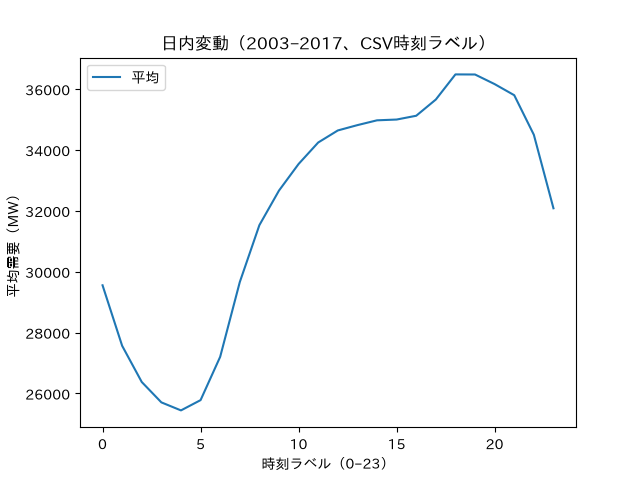

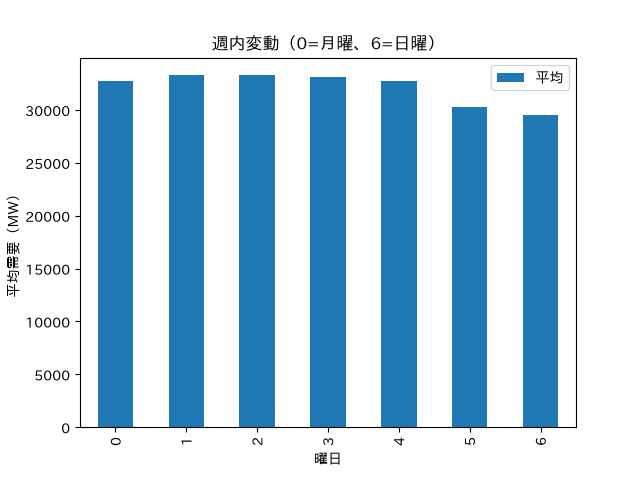

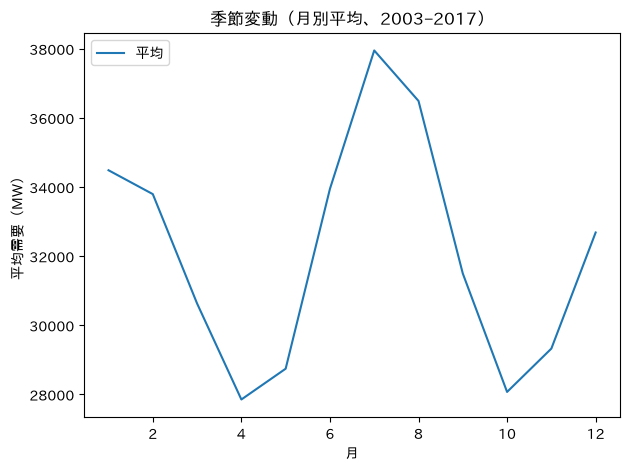

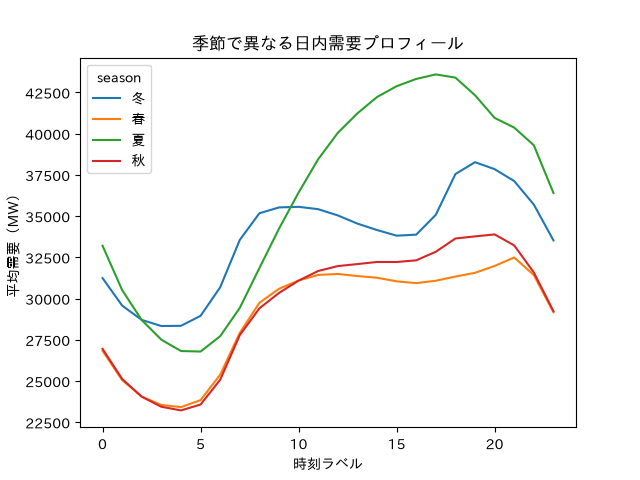

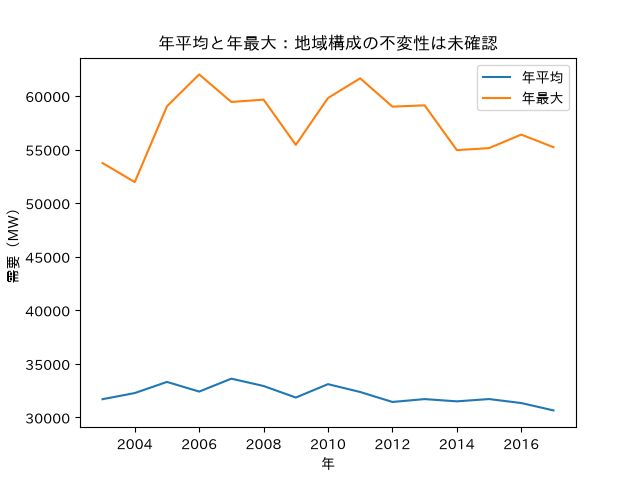

In [10]:
begin_phase('図表作成')
from ai_data_scientist import visualization
import warnings
import matplotlib.pyplot as plt
try:
    chart_specs = [
        (hour_profile.reset_index().rename(columns={'mean':'平均'}), 'line', 'hour', ['平均'], '日内変動（2003–2017、CSV時刻ラベル）', '時刻ラベル（0–23）', '平均需要（MW）'),
        (weekday_profile.reset_index().rename(columns={'mean':'平均'}), 'bar', 'weekday', ['平均'], '週内変動（0=月曜、6=日曜）', '曜日', '平均需要（MW）'),
        (month_profile.reset_index().rename(columns={'mean':'平均'}), 'line', 'month', ['平均'], '季節変動（月別平均、2003–2017）', '月', '平均需要（MW）'),
        (seasonal_hour.reset_index(), 'line', 'hour', ['冬','春','夏','秋'], '季節で異なる日内需要プロフィール', '時刻ラベル', '平均需要（MW）'),
        (annual.reset_index().rename(columns={'mean':'年平均','max':'年最大'}), 'line', 'year', ['年平均','年最大'], '年平均と年最大：地域構成の不変性は未確認', '年', '需要（MW）')
    ]
    chart_warnings = []
    for frame,kind,x,y,title,xlabel,ylabel in chart_specs:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            if title.startswith('季節変動'):
                fig, ax = plt.subplots()
                ax.plot(frame[x], frame[y[0]], label=y[0])
                ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
                ax.legend(loc='upper left')
                fig.tight_layout()
                buffer = io.BytesIO()
                fig.savefig(buffer, format='png', bbox_inches='tight')
                plt.close(fig)
                png = buffer.getvalue()
            else:
                png = visualization.render_chart(frame, kind=kind, x=x, y=y, title=title, xlabel=xlabel, ylabel=ylabel)
        chart_warnings.extend(str(w.message) for w in caught if 'Glyph' in str(w.message))
        output = visualization.build_image_output(png)
        display(output['data'], raw=True)
    print({'chart_count': len(chart_specs), 'missing_glyph_warnings': chart_warnings, 'chart_scope': '全図はnaive時刻、平均と最大はMW。補間なし'})
finally:
    end_phase('図表作成')

In [11]:
# 反復依頼履歴：反復1（初回結果を読み直して選定）
iteration_history = []
request1 = '春の03時欠落と秋の02時重複・欠落は夏時間とhour-endingラベルに対応するか確認してください。時計切替日を除外し、重複時刻の平均・先頭・最大、時刻ラベルの0時間・1時間シフト、全15年・直近5年を比較して、日内・週内・季節の結論が変わるか検証してください。UTCを推測で確定しないでください。'
print('反復依頼原文1=' + request1)
print('選定理由1=欠損ゼロの列でも時刻ラベルの欠落・重複があり、ピーク時刻の解釈に実質的な影響がある。')
begin_phase('反復1：時刻定義と感度分析')
from ai_data_scientist import sensitivity
from zoneinfo import ZoneInfo
try:
    zone = ZoneInfo('America/New_York')
    all_days = pd.date_range('2002-01-01', '2018-12-31', freq='D')
    offsets = pd.Series([datetime(d.year,d.month,d.day,12,tzinfo=zone).utcoffset().total_seconds() for d in all_days], index=all_days)
    spring_days = offsets.index[offsets.diff() > 0]
    fall_days = offsets.index[offsets.diff() < 0]
    dst_days = spring_days.union(fall_days)
    gap_checks = pd.DataFrame({'missing_time': missing_times})
    gap_checks['classification'] = ['春切替日の03時（hour-ending候補）' if t.normalize() in spring_days and t.hour == 3 else '秋切替日の02時（2002–2013はラベル自体なし）' if t.normalize() in fall_days and t.hour == 2 else '時計切替では説明できない欠落' for t in missing_times]
    duplicate_alignment = bool(duplicate_rows.Datetime.dt.normalize().isin(fall_days).all() and (duplicate_rows.Datetime.dt.hour == 2).all())
    timezone_hypothesis = {}
    for shift in [0,-1]:
        candidate = pd.DatetimeIndex(clean.Datetime) + pd.Timedelta(hours=shift)
        nonexistent_or_ambiguous = candidate.tz_localize('America/New_York', ambiguous='NaT', nonexistent='NaT').isna()
        timezone_hypothesis[str(shift)] = {'unresolvable_rows': int(nonexistent_or_ambiguous.sum()), 'note': 'NaTは曖昧/存在しない時刻を表す。正しいUTC復元を意味しない'}
    def specification_frame(duplicate_policy='mean', shift=0, exclude_dst=False, period='all'):
        if duplicate_policy == 'mean':
            s = clean.groupby('Datetime').PJME_MW.mean()
        elif duplicate_policy == 'first':
            s = clean.drop_duplicates('Datetime', keep='first').set_index('Datetime').PJME_MW
        elif duplicate_policy == 'max':
            s = clean.groupby('Datetime').PJME_MW.max()
        else:
            raise ValueError('未定義の重複方針')
        original_index = s.index
        if exclude_dst:
            s = s.loc[~original_index.normalize().isin(dst_days)]
        s.index = s.index + pd.Timedelta(hours=shift)
        start_year = 2003 if period == 'all' else 2013
        s = s.loc[(s.index.year >= start_year) & (s.index.year <= 2017)]
        return s.to_frame('MW').assign(hour=s.index.hour, weekday=s.index.dayofweek, month=s.index.month, year=s.index.year)
    def weekend_stat(**spec):
        d = specification_frame(**spec)
        return (d.loc[d.weekday>=5,'MW'].mean() / d.loc[d.weekday<5,'MW'].mean() - 1) * 100
    sensitivity_plan = sensitivity.SensitivityPlan(parameter_grid={'duplicate_policy':['mean','first','max'], 'shift':[0,-1], 'exclude_dst':[False,True], 'period':['all','recent']}, max_runs=24)
    sensitivity_report = sensitivity.run_sensitivity(sensitivity_plan, weekend_stat, stability_tolerance=.20)
    specification_results = []
    for r in sensitivity_report.results:
        d = specification_frame(**r.specification)
        specification_results.append({**r.specification, 'weekend_pct': r.value, 'peak_hour': int(d.groupby('hour').MW.mean().idxmax()), 'max_month': int(d.groupby('month').MW.mean().idxmax()), 'min_month': int(d.groupby('month').MW.mean().idxmin())})
    sensitivity_table = pd.DataFrame(specification_results)
    iter1_results = {'gap_classification_counts': gap_checks.classification.value_counts().to_dict(), 'all_duplicate_times_align_fall_02': duplicate_alignment, 'timezone_hypotheses': timezone_hypothesis, 'weekend_difference_pct_range': [float(sensitivity_table.weekend_pct.min()), float(sensitivity_table.weekend_pct.max())], 'summer_max_month_unique': sorted(sensitivity_table.max_month.unique().tolist()), 'trough_month_unique': sorted(sensitivity_table.min_month.unique().tolist()), 'peak_hours_by_shift': {str(k): sorted(g.peak_hour.unique().tolist()) for k,g in sensitivity_table.groupby('shift')}, 'stable': sensitivity_report.stable, 'max_relative_deviation': sensitivity_report.max_relative_deviation, 'specifications': len(sensitivity_report.results)}
    print('ITERATION1_RESULTS=' + json.dumps(iter1_results, ensure_ascii=False))
    display(gap_checks)
    display(sensitivity_table.round(4))
    iteration_history.append({'iteration':1,'request':request1,'selection_reason':'夏時間・hour-ending・重複処理が時刻と需要差を歪め得る','result':iter1_results,'evidence':'ITERATION1_RESULTS、gap_checks、sensitivity_table','remaining_limit':'America/New_Yorkとhour-endingは値の整合性仮説であり出典による確定ではない。秋の2観測をUTC順へ復元しない。'})
finally:
    end_phase('反復1：時刻定義と感度分析')

反復依頼原文1=春の03時欠落と秋の02時重複・欠落は夏時間とhour-endingラベルに対応するか確認してください。時計切替日を除外し、重複時刻の平均・先頭・最大、時刻ラベルの0時間・1時間シフト、全15年・直近5年を比較して、日内・週内・季節の結論が変わるか検証してください。UTCを推測で確定しないでください。
選定理由1=欠損ゼロの列でも時刻ラベルの欠落・重複があり、ピーク時刻の解釈に実質的な影響がある。
ITERATION1_RESULTS={"gap_classification_counts": {"春切替日の03時（hour-ending候補）": 17, "秋切替日の02時（2002–2013はラベル自体なし）": 12, "時計切替では説明できない欠落": 1}, "all_duplicate_times_align_fall_02": true, "timezone_hypotheses": {"0": {"unresolvable_rows": 33, "note": "NaTは曖昧/存在しない時刻を表す。正しいUTC復元を意味しない"}, "-1": {"unresolvable_rows": 8, "note": "NaTは曖昧/存在しない時刻を表す。正しいUTC復元を意味しない"}}, "weekend_difference_pct_range": [-9.64644467815151, -9.04253985080734], "summer_max_month_unique": [7], "trough_month_unique": [4], "peak_hours_by_shift": {"-1": [17], "0": [18]}, "stable": true, "max_relative_deviation": 0.053133817000832514, "specifications": 24}


,missing_time,classification
0,2002-04-07 03:00:00,春切替日の03時（hour-ending候補）
1,2002-10-27 02:00:00,秋切替日の02時（2002–2013はラベル自体なし）
2,2003-04-06 03:00:00,春切替日の03時（hour-ending候補）
3,2003-10-26 02:00:00,秋切替日の02時（2002–2013はラベル自体なし）
4,2004-04-04 03:00:00,春切替日の03時（hour-ending候補）
5,2004-10-31 02:00:00,秋切替日の02時（2002–2013はラベル自体なし）
6,2005-04-03 03:00:00,春切替日の03時（hour-ending候補）
7,2005-10-30 02:00:00,秋切替日の02時（2002–2013はラベル自体なし）
8,2006-04-02 03:00:00,春切替日の03時（hour-ending候補）
9,2006-10-29 02:00:00,秋切替日の02時（2002–2013はラベル自体なし）


,duplicate_policy,shift,exclude_dst,period,weekend_pct,peak_hour,max_month,min_month
0,mean,0,False,all,-9.5500,18,7,4
1,mean,0,False,recent,-9.1878,18,7,4
2,mean,0,True,all,-9.3879,18,7,4
3,mean,0,True,recent,-9.0425,18,7,4
4,mean,-1,False,all,-9.6464,17,7,4
5,mean,-1,False,recent,-9.2848,17,7,4
6,mean,-1,True,all,-9.4858,17,7,4
7,mean,-1,True,recent,-9.1410,17,7,4
8,first,0,False,all,-9.5499,18,7,4
9,first,0,False,recent,-9.1877,18,7,4


In [12]:
# 反復依頼履歴：反復2（反復1を読み直して選定）
request2 = '日内・週内・季節の特徴が未知期間の需要予測にどの程度使えるか、2015年・2016年・2017年の時間順ホールドアウトで検証してください。学習期間だけで作った月×曜日×時刻平均（全過去と直近3年）を、前日同時刻・前週同時刻の逐次予測と共通の評価時刻で比較してください。通常時のMAE・WAPE・バイアスに加え、学習期間99パーセンタイル以上の高需要時の誤差を示し、情報漏洩と予測の発行時点を明記してください。2018年の途中期間は別枠で確認してください。'
print('反復依頼原文2=' + request2)
print('選定理由2=記述的な周期性だけでは未知期間での予測価値やピーク時の性能を保証できない。')
begin_phase('反復2：未知年バックテスト')
try:
    forecast_metrics = []
    fold_predictions = []
    fold_quality = []
    for test_year in [2015,2016,2017,2018]:
        train = hourly.loc[(hourly.year >= 2003) & (hourly.year < test_year)].dropna(subset=['MW'])
        test = hourly.loc[hourly.year == test_year].copy()
        keys = ['month','weekday','hour']
        target_index = pd.MultiIndex.from_frame(test[keys])
        pred = pd.DataFrame(index=test.index)
        pred['actual'] = test.MW
        pred['calendar_all'] = train.groupby(keys).MW.mean().reindex(target_index).to_numpy()
        recent_train = train.loc[train.year >= test_year-3]
        pred['calendar_recent3'] = recent_train.groupby(keys).MW.mean().reindex(target_index).to_numpy()
        pred['lag24'] = series.reindex(test.index-pd.Timedelta(hours=24)).to_numpy()
        pred['lag168'] = series.reindex(test.index-pd.Timedelta(hours=168)).to_numpy()
        no_transition_day = ~test.index.normalize().isin(dst_days)
        for lag in [24,168]:
            no_transition_day &= ~(test.index-pd.Timedelta(hours=lag)).normalize().isin(dst_days)
        eval_mask = pred.notna().all(axis=1) & no_transition_day
        eligible = pred.loc[eval_mask].copy()
        train_peak_threshold = float(train.MW.quantile(.99))
        eligible['is_peak'] = eligible.actual >= train_peak_threshold
        eligible['test_year'] = test_year
        fold_quality.append({'test_year':test_year, 'train_rows':len(train), 'test_rows':len(test), 'eligible_rows':len(eligible), 'removed_rows':int((~eval_mask).sum()), 'high_demand_rows':int(eligible.is_peak.sum()), 'train99_MW':train_peak_threshold, 'test_period': [str(test.index.min()),str(test.index.max())]})
        for model in ['calendar_all','calendar_recent3','lag24','lag168']:
            error = eligible[model]-eligible.actual
            peak_error = error.loc[eligible.is_peak]
            forecast_metrics.append({'test_year':test_year,'model':model,'n':len(error),'MAE_MW':float(error.abs().mean()),'RMSE_MW':float(np.sqrt((error**2).mean())),'WAPE_pct':float(error.abs().sum()/eligible.actual.sum()*100),'bias_MW':float(error.mean()),'peak_n':len(peak_error),'peak_MAE_MW':float(peak_error.abs().mean()),'peak_bias_MW':float(peak_error.mean()),'worst_underforecast_MW':float((-error).clip(lower=0).max())})
        fold_predictions.append(eligible)
    forecast_table = pd.DataFrame(forecast_metrics)
    prediction_panel = pd.concat(fold_predictions)
    display(pd.DataFrame(fold_quality))
    display(forecast_table.round(2))
    overall_metrics = []
    primary_prediction = prediction_panel.loc[prediction_panel.test_year <= 2017]
    for model in ['calendar_all','calendar_recent3','lag24','lag168']:
        error = primary_prediction[model]-primary_prediction.actual
        peak_error = error.loc[primary_prediction.is_peak]
        overall_metrics.append({'model':model,'MAE_MW':float(error.abs().mean()),'WAPE_pct':float(error.abs().sum()/primary_prediction.actual.sum()*100),'bias_MW':float(error.mean()),'peak_MAE_MW':float(peak_error.abs().mean()),'peak_bias_MW':float(peak_error.mean()),'n':len(error),'peak_n':len(peak_error)})
    overall_table = pd.DataFrame(overall_metrics)
    print('ITERATION2_RESULTS=' + json.dumps(overall_metrics, ensure_ascii=False))
    print('発行条件=lag24/lag168は各対象日の前日までの実測が順次利用可能な日次更新ベースライン。年初に一年全体を予測する実験ではない。calendarモデルは各年の前年末で固定。DST付近は除外、残る時刻はローカルラベルでありUTC等間隔とは未確定。')
    iteration_history.append({'iteration':2,'request':request2,'selection_reason':'未知期間性能・ピーク誤差を実測する必要','result':overall_metrics,'evidence':'ITERATION2_RESULTS、forecast_table、fold_quality','remaining_limit':'3完全年と2018年途中だけ。気象・祝日未使用、現時点2026年や別地域への一般化不可。逐次観測が必要なlagを固定長期予測と混同しない。'})
    forecast_table.to_csv(data_dir/'forecast-metrics.csv',index=False)
finally:
    end_phase('反復2：未知年バックテスト')

反復依頼原文2=日内・週内・季節の特徴が未知期間の需要予測にどの程度使えるか、2015年・2016年・2017年の時間順ホールドアウトで検証してください。学習期間だけで作った月×曜日×時刻平均（全過去と直近3年）を、前日同時刻・前週同時刻の逐次予測と共通の評価時刻で比較してください。通常時のMAE・WAPE・バイアスに加え、学習期間99パーセンタイル以上の高需要時の誤差を示し、情報漏洩と予測の発行時点を明記してください。2018年の途中期間は別枠で確認してください。
選定理由2=記述的な周期性だけでは未知期間での予測価値やピーク時の性能を保証できない。
ITERATION2_RESULTS=[{"model": "calendar_all", "MAE_MW": 3016.664172139474, "WAPE_pct": 9.640746269668135, "bias_MW": 1056.879722464151, "peak_MAE_MW": 8609.32980175009, "peak_bias_MW": -8609.32980175009, "n": 25872, "peak_n": 181}, {"model": "calendar_recent3", "MAE_MW": 2929.622166507863, "WAPE_pct": 9.362574805026034, "bias_MW": 312.5772504094802, "peak_MAE_MW": 10294.245038754983, "peak_bias_MW": -10294.245038754983, "n": 25872, "peak_n": 181}, {"model": "lag24", "MAE_MW": 2149.9733302411873, "WAPE_pct": 6.870949559064934, "bias_MW": 0.5882807668521954, "peak_MAE_MW": 3315.646408839779, "peak_bias_MW": -2655.745856353591, "n": 25872, "peak_n": 181}, {"model": "lag168", "MAE_MW": 3373.230132962276, "WAPE_pct"

,test_year,train_rows,test_rows,eligible_rows,removed_rows,high_demand_rows,train99_MW,test_period
0,2015,105168,8760,8616,144,33,51303.65,"[2015-01-01 00:00:00, 2015-12-31 23:00:00]"
1,2016,113927,8784,8640,144,112,51138.22,"[2016-01-01 00:00:00, 2016-12-31 23:00:00]"
2,2017,122710,8760,8616,144,36,51207.73,"[2017-01-01 00:00:00, 2017-12-31 23:00:00]"
3,2018,131469,5137,5065,72,35,51071.92,"[2018-01-01 00:00:00, 2018-08-03 00:00:00]"


,test_year,model,n,MAE_MW,RMSE_MW,WAPE_pct,bias_MW,peak_n,peak_MAE_MW,peak_bias_MW,worst_underforecast_MW
0,2015,calendar_all,8616,2986.57,3796.63,9.40,626.89,33,8703.71,-8703.71,15367.98
1,2015,calendar_recent3,8616,2792.03,3733.55,8.79,-189.77,33,9491.57,-9491.57,15927.54
2,2015,lag24,8616,2187.69,3006.47,6.88,8.90,33,3997.48,-3883.06,10919.00
3,2015,lag168,8616,3315.67,4458.12,10.43,17.49,33,7036.06,-7036.06,20346.00
4,2016,calendar_all,8640,2944.07,3723.15,9.37,942.90,112,8914.51,-8914.51,16606.33
5,2016,calendar_recent3,8640,3004.47,4040.18,9.56,261.84,112,11064.89,-11064.89,18318.50
6,2016,lag24,8640,2087.29,2866.98,6.64,12.40,112,3227.96,-2390.55,14719.00
7,2016,lag168,8640,3337.36,4624.17,10.62,-56.90,112,8432.29,-8409.05,19120.00
8,2017,calendar_all,8616,3119.56,3895.94,10.17,1601.17,36,7573.35,-7573.35,13617.44
9,2017,calendar_recent3,8616,2992.16,3917.31,9.75,865.80,36,8632.48,-8632.48,15003.79


In [13]:
# 反復依頼履歴：反復3（反復2を読み直して選定）
request3 = '高需要時の過小予測が大きいため、需要ピークを95・99・99.5パーセンタイルで定義した場合と全期間・直近5年で、夏・平日・夕方への集中が保たれるか確認してください。99パーセンタイル超過の連続エピソードと日別ピークを調べ、時間数を独立な事象数と混同しないでください。未知年の高需要誤差も閾値を変えて確認し、暦平均と前日同時刻予測の優劣が逆転しないか示してください。'
print('反復依頼原文3=' + request3)
print('選定理由3=ピーク閾値・年構成・連続する観測の依存性がピーク集中率と予測限界の強さを変え得る。')
begin_phase('反復3：ピーク定義と連続事象')
try:
    peak_rows = []
    def summer_peak_share(quantile=.99, period='all'):
        d = main if period == 'all' else main.loc[main.year >= 2013]
        limit = float(d.MW.quantile(quantile))
        h = d.loc[d.MW >= limit]
        peak_rows.append({'quantile':quantile,'period':period,'threshold_MW':limit,'n_hours':len(h),'n_days':h.index.normalize().nunique(),'summer_share':float(h.month.isin([6,7,8]).mean()),'weekday_share':float((h.weekday<5).mean()),'15_to_20_share':float(h.hour.between(15,20).mean())})
        return float(h.month.isin([6,7,8]).mean())
    peak_plan = sensitivity.SensitivityPlan(parameter_grid={'quantile':[.99,.95,.995], 'period':['all','recent']}, max_runs=6)
    peak_report = sensitivity.run_sensitivity(peak_plan, summer_peak_share, stability_tolerance=.20)
    peak_sensitivity_table = pd.DataFrame(peak_rows)
    main_grid = series.loc['2003-01-01':'2017-12-31 23:00:00']
    above = main_grid >= threshold99
    starts = above & ~above.shift(1,fill_value=False)
    episode_ids = starts.cumsum()
    episode_frame = main_grid.loc[above].to_frame('MW').assign(episode=episode_ids.loc[above])
    episode_table = episode_frame.reset_index().groupby('episode').agg(start=('Datetime','min'),end=('Datetime','max'),n_label_hours=('MW','size'),maximum_MW=('MW','max'))
    daily = main_grid.resample('D').agg(['mean','max','count'])
    full_days = daily.loc[(daily['count'] == 24) & ~daily.index.isin(dst_days)]
    daily_peak_records = main.loc[main.index.normalize().isin(full_days.index)].reset_index()
    daily_peak_records['day'] = daily_peak_records.Datetime.dt.normalize()
    daily_peak_records = daily_peak_records.loc[daily_peak_records.groupby('day').MW.idxmax()]
    daily_peak_summary = {'eligible_24label_days':len(full_days), 'excluded_incomplete_days':int(len(daily) - len(full_days)), 'daily_peak_hour_mode':int(daily_peak_records.hour.mode().iloc[0]), 'daily_mean_max_MW':float(full_days['mean'].max()), 'hourly_max_MW':float(main_grid.max()), 'smoothing_loss_pct':float((1-full_days['mean'].max()/main_grid.max())*100), 'episodes99':len(episode_table), 'max_episode_label_hours':int(episode_table.n_label_hours.max()), 'median_episode_label_hours':float(episode_table.n_label_hours.median()), 'max_episode_record':episode_table.loc[episode_table.maximum_MW.idxmax()].astype(str).to_dict(), 'summer_share_stable':peak_report.stable,'summer_share_max_relative_deviation':peak_report.max_relative_deviation}
    peak_forecast_rows = []
    for q in [.95,.99,.995]:
        q_panels = []
        for y in [2015,2016,2017]:
            train_y = hourly.loc[(hourly.year >= 2003)&(hourly.year<y)].MW.dropna()
            limit_y = float(train_y.quantile(q))
            part = prediction_panel.loc[(prediction_panel.test_year==y)&(prediction_panel.actual>=limit_y)]
            q_panels.append(part)
        p = pd.concat(q_panels)
        for model in ['calendar_all','calendar_recent3','lag24','lag168']:
            error = p[model]-p.actual
            peak_forecast_rows.append({'quantile':q,'model':model,'high_demand_n':len(p),'MAE_MW':float(error.abs().mean()),'bias_MW':float(error.mean())})
    peak_forecast_table = pd.DataFrame(peak_forecast_rows)
    print('ITERATION3_RESULTS=' + json.dumps(daily_peak_summary, ensure_ascii=False))
    display(peak_sensitivity_table.round(4))
    display(episode_table.nlargest(10,'maximum_MW'))
    display(peak_forecast_table.assign(quantile=peak_forecast_table['quantile'].map(lambda q: f'{q*100:g}%')).round(2))
    print('停止判断=3回の反復で時刻解釈、仕様感度、未知年性能、ピーク閾値と連続性を確認。残る重要点は原資料のタイムゾーン・計測定義、地域境界、気象・祝日・新しい期間の未取得であり、同じ2列だけの追加分析では解決できない。')
    iteration_history.append({'iteration':3,'request':request3,'selection_reason':'閾値依存・年差・ピークの連続性を確認','result':daily_peak_summary,'evidence':'ITERATION3_RESULTS、peak_sensitivity_table、episode_table、peak_forecast_table','remaining_limit':'連続時間はnaiveラベル上。極値は標本最大で設計限界や将来最大ではない。独立参照・気象データなし。'})
    episode_table.to_csv(data_dir/'peak-episodes.csv')
    peak_sensitivity_table.to_csv(data_dir/'peak-sensitivity.csv',index=False)
    (data_dir/'iteration-history.json').write_text(json.dumps(iteration_history, ensure_ascii=False, indent=2),encoding='utf-8')
finally:
    end_phase('反復3：ピーク定義と連続事象')

反復依頼原文3=高需要時の過小予測が大きいため、需要ピークを95・99・99.5パーセンタイルで定義した場合と全期間・直近5年で、夏・平日・夕方への集中が保たれるか確認してください。99パーセンタイル超過の連続エピソードと日別ピークを調べ、時間数を独立な事象数と混同しないでください。未知年の高需要誤差も閾値を変えて確認し、暦平均と前日同時刻予測の優劣が逆転しないか示してください。
選定理由3=ピーク閾値・年構成・連続する観測の依存性がピーク集中率と予測限界の強さを変え得る。
ITERATION3_RESULTS={"eligible_24label_days": 5448, "excluded_incomplete_days": 31, "daily_peak_hour_mode": 19, "daily_mean_max_MW": 52229.833333333336, "hourly_max_MW": 62009.0, "smoothing_loss_pct": 15.77056018749966, "episodes99": 221, "max_episode_label_hours": 14, "median_episode_label_hours": 6.0, "max_episode_record": {"start": "2006-08-02 10:00:00", "end": "2006-08-02 23:00:00", "n_label_hours": "14", "maximum_MW": "62009.0"}, "summer_share_stable": true, "summer_share_max_relative_deviation": 0.19355740066505753}
停止判断=3回の反復で時刻解釈、仕様感度、未知年性能、ピーク閾値と連続性を確認。残る重要点は原資料のタイムゾーン・計測定義、地域境界、気象・祝日・新しい期間の未取得であり、同じ2列だけの追加分析では解決できない。


,quantile,period,threshold_MW,n_hours,n_days,summer_share,weekday_share,15_to_20_share
0,0.990,all,51071.920,1315,221,0.9498,0.9323,0.7323
1,0.990,recent,49890.660,439,77,0.8770,0.8975,0.7813
2,0.950,all,44167.000,6575,813,0.8666,0.8824,0.6056
3,0.950,recent,43264.000,2192,291,0.7660,0.8805,0.6182
4,0.995,all,53267.960,658,123,0.9772,0.9453,0.7629
5,0.995,recent,51763.915,220,46,0.9091,0.9182,0.8136


,start,end,n_label_hours,maximum_MW
episode,,,,
48,2006-08-02 10:00:00,2006-08-02 23:00:00,14,62009.0
49,2006-08-03 10:00:00,2006-08-03 22:00:00,13,61796.0
140,2011-07-22 10:00:00,2011-07-22 23:00:00,14,61646.0
47,2006-08-01 11:00:00,2006-08-01 23:00:00,13,61643.0
139,2011-07-21 11:00:00,2011-07-21 23:00:00,13,60689.0
39,2006-07-18 11:00:00,2006-07-18 20:00:00,10,59943.0
103,2010-07-06 11:00:00,2010-07-06 22:00:00,12,59807.0
77,2008-06-10 11:00:00,2008-06-10 20:00:00,10,59655.0
69,2007-08-08 11:00:00,2007-08-08 22:00:00,12,59437.0


,quantile,model,high_demand_n,MAE_MW,bias_MW
0,95%,calendar_all,1099,5723.44,-5449.14
1,95%,calendar_recent3,1099,7144.77,-6978.13
2,95%,lag24,1099,3439.48,-2068.95
3,95%,lag168,1099,7036.02,-5985.65
4,99%,calendar_all,181,8609.33,-8609.33
5,99%,calendar_recent3,181,10294.25,-10294.25
6,99%,lag24,181,3315.65,-2655.75
7,99%,lag168,181,8619.15,-8604.77
8,99.5%,calendar_all,50,10150.24,-10150.24
9,99.5%,calendar_recent3,50,12124.92,-12124.92


In [14]:
begin_phase('証拠整理と改善候補再現')
from ai_data_scientist import insight_engine, notebook_audit
try:
    final_assumptions = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={**assumptions.analysis_scope, 'backtest':'2015–2017完全年、2018途中別枠', 'forecast_origin':'各日前日までの実測で日次更新、暦平均は前年末固定'},
        assumptions=tuple(analysis_assumptions.Assumption(a.id,a.statement,'tested' if a.id=='duplicates_small' else a.status,a.evidence_cell,a.impact_if_false,a.conclusion_critical) for a in assumptions.assumptions) + (analysis_assumptions.Assumption('peak_threshold','95/99/99.5%と全15年/直近5年で集中の向きを確認','tested',impact_if_false='ピーク集中率の強度は変動する',conclusion_critical=True),analysis_assumptions.Assumption('no_leakage','学習は各テスト年より前、閾値も学習データのみ、lag入力は対象日前日までに観測可能','verified',conclusion_critical=True)),causal_scope='descriptive')
    final_assumption_findings = analysis_assumptions.check_manifest(final_assumptions)
    print('FINAL_ASSUMPTION_FINDINGS=' + json.dumps([asdict(a) for a in final_assumption_findings],ensure_ascii=False))
    nb_snapshot = nbformat.read(handle.notebook_path, as_version=4)
    setup_cell = next(c for c in nb_snapshot.cells if c.cell_type=='code' and c.source.startswith('from pathlib import Path'))
    improvement_candidates = []
    try:
        insight_engine.record_insight(handle,'再現テスト：実行済みprint出力の証拠照合',setup_cell.execution_count,'v020-exp-42','descriptive',language='ja')
        stream_reproduction = '期待した拒否は発生しなかった'
    except insight_engine.EvidenceMissingError as exc:
        stream_reproduction = type(exc).__name__
        improvement_candidates.append({'classification':'機能不足（証拠照合）','reproduction':'setupセルの実行済みstream出力にv020-exp-42がある状態でrecord_insightを呼ぶ','expected':'stream.text内の引用値も証拠として照合する、または非対応をAPI仕様で明示','actual':stream_reproduction,'impact':'print中心の分析で根拠がある結論を記録できない','workaround':'根拠をtext/plainのdisplay_dataとして明示的に保存し、extract_cited_valueで抽出','related_cells':'setup、証拠整理、結果証拠セル','log':'STREAM_EVIDENCE_REPRODUCTION'})
    chart_index = next(i for i,c in enumerate(nb_snapshot.cells) if c.cell_type=='code' and c.source.startswith("begin_phase('図表作成')"))
    metadata_probe = nbformat.v4.new_notebook(cells=[nbformat.from_dict(dict(nb_snapshot.cells[chart_index]))])
    metadata_probe.cells[0].metadata.pop('chart',None)
    absent_metadata_findings = notebook_audit.audit_visual_outputs(metadata_probe,(0,))
    if not absent_metadata_findings:
        improvement_candidates.append({'classification':'機能不足（視覚監査の偽陰性）','reproduction':'画像出力があるセルでmetadata.chartを削除しaudit_visual_outputsを実行','expected':'glyph/title/xlabel/ylabel/legendの監査情報が未設定なら検査不能として警告または失敗','actual':'visual_findingsは空、監査情報欠落を検出しない','impact':'visual_audit=Trueだけではラベル・フォント監査が実施された証明にならない','workaround':'各図の著者メタデータをenqueue_writeで記録し、glyph警告を実測、図を目視確認','related_cells':'図表作成、証拠整理、最終監査','log':'VISUAL_METADATA_REPRODUCTION'})
    print('STREAM_EVIDENCE_REPRODUCTION=' + stream_reproduction)
    print('VISUAL_METADATA_REPRODUCTION=' + json.dumps([asdict(a) for a in absent_metadata_findings],ensure_ascii=False))
    improvement_candidates.append({'classification':'機能不足候補（図表レイアウト）','reproduction':'月別折れ線のrender_chart出力で右上凡例が欠けて見え、凡例を短縮して再描画しても改善しなかった','expected':'凡例位置・余白・tight layoutを指定でき、ラベルが読み取れるPNGを作れる','actual':'render_chartの公開引数にlegend位置/保存時bbox指定がなく、視覚監査も位置や切れを検査しない','impact':'月別図の凡例可読性が低下する疑い。統計値には影響なし','workaround':'月別図だけ同じデータからMatplotlibでupper-left凡例、tight_layout、bbox_inches=tightで再描画。PNG再表示で確認','related_cells':'図表作成、証拠整理、最終監査','log':'初回月別PNG sha256先頭11b8496a54eacb99、短縮後157f94f6f8cfddc2。CLI画像表示の影響は未分離なので確定不具合ではなく機能不足候補とする'})
    print('JUPYTERMIND_IMPROVEMENTS=' + json.dumps(improvement_candidates,ensure_ascii=False))
    print('適用外=独立データ比較・異常の独立検証：別の独立参照データが提示/取得されていない。因果推論：識別設計なし。MWh積算：時間平均の定義とUTC復元が未確認。将来の気象効果：説明変数なし。mcp_gateway.run_and_record：この呼出環境は直接Jupyter MCPツールであり、カーネル内にMCPClientを渡せないため未使用（使用済みには数えない）。')
    print('外部固有問題=初回dataset_listのpage_size非対応TypeErrorはKaggle SDK呼出の互換問題でありJupytermindではない。Notebook親ディレクトリ未作成はJupyter MCP/CLI準備、filesystemの許可root相違はツール設定。ベンチマークランナーは実行していない。')
    def record_documents_and_metadata():
        def mutate(nb):
            headings = ('# 分析概要', '## 使用したJupytermindモジュール','## Jupytermind改善候補','## 反復依頼履歴','## 前提・適用範囲と未知期間への限界','## 取得情報とデータ品質','## 監査記録')
            nb.cells = [c for c in nb.cells if not (c.cell_type=='markdown' and (c.source.startswith(headings) or c.metadata.get('generated_by')=='v020-exp-42'))]
            overview = '# 分析概要\n\nPJMの公開時間別電力需要を用いた日内・週内・季節変動、極端需要と未知年バックテスト。対象はPJME_hourly.csvの1地域であり、PJM全域や各家庭の代表値ではありません。実行はJupyter MCPのみ。run_id: `v020-exp-42`。\n\n主分析は2003–2017年。2018年は1月〜8月途中なので季節分析から除き、予測評価だけ別枠にしました。出典：[Kaggle Hourly Energy Consumption](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption)。'
            nb.cells.insert(0,nbformat.v4.new_markdown_cell(overview))
            info = '## 取得情報とデータ品質\n\n```json\n' + json.dumps(provenance,ensure_ascii=False,indent=2) + '\n```\n\n取得日（日本時間）: ' + datetime.fromisoformat(provenance['retrieved_at_utc']).astimezone(ZoneInfo('Asia/Tokyo')).isoformat() + '\n\n145,366行、2002-01-01 01:00から2018-08-03 00:00。列の欠損は0ですが、naive時間ラベルに30欠落・4重複時刻（8行）、元行順は未整列。完全同一行の削除0。分析ラベル系列は重複平均、欠落はNaNで保持し補間しません。17欠落は米東部春切替日03時、12欠落は秋切替日02時、残りは2010-12-10 00時。秋の重複4時刻はいずれも切替日02時。夏時間とhour-ending仮説とは整合しますがタイムゾーン確定の証拠ではありません。\n\n単位は出典によりMW（電力）。hourlyは確認済みですが、時間平均/瞬時値とhour-start/hour-endは未確定。日・月の集計は算術平均MW、需要ピークは元の時間別値の最大。MWhへ積算しません。生CSV・metadata・manifestは同プロジェクトのdataディレクトリに保存。トークン・認証例外詳細は保存/表示しません。SHA-256は再実行でも照合します。'
            module_text = '## 使用したJupytermindモジュール\n\n直接import・呼び出したものだけを列挙します。間接利用は含めません。\n\n| モジュール（ai_data_scientist配下） | 直接呼び出した関数・クラス | 使用目的 |\n|---|---|---|\n| project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 固定rootでプロジェクト解決・Notebook/data作成・文書/メタデータの直列書込み |\n| language_router | detect_language | 日本語の判定 |\n| lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, get_run_status, mark_completed, mark_failed | run_id、実行/書込み相、終了状態管理 |\n| ingestion | SourceSpec, ingest | CSV全行読込、200000行上限で切捨てなし確認 |\n| cleaning | clean_dataset | 完全同一行重複削除と影響0行の記録 |\n| eda | explore | 列型・要約・欠損探索 |\n| data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 単位・時刻・測定定義のverified/inferred/unknown区分 |\n| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 非因果の適用範囲・重要な未確認前提の明示 |\n| data_quality | detect_anomalies | 時刻一意性・not_null・需要非負の意味的制約検査 |\n| sensitivity | SensitivityPlan, run_sensitivity | 時刻/重複/年範囲24条件、ピーク閾値/期間6条件 |\n| visualization | render_chart, build_image_output | 日本語の図表生成・PNG MIME表示 |\n| insight_engine | extract_cited_value, record_insight | 実出力からの引用、証拠付き結論記録、stream非対応の再現 |\n| notebook_audit | audit_visual_outputs, audit_notebook | 視覚監査情報欠落の再現、visual_audit=Trueで全Notebook監査 |'
            caveats = '## 前提・適用範囲と未知期間への限界\n\nDataDefinitionManifestとAnalysisAssumptionManifestはコード出力とdata内JSONに保存。unresolved_fieldsはunknownのみを返す実装なので、inferredも別に列挙しました。check_manifestの最終警告はtimestamp_localとstable_regionの2件であり、隠しません。時刻ラベルを現地時刻の代理とする点と地域境界の年次不変性は未確認です。重複処理の小影響は感度分析でtestedへ更新しました。\n\n需要予測の入力候補は時刻・曜日・月/季節、その交互作用、前日/前週同時刻値、過去のみのローリング需要と直近水準です。暦は未来に既知ですが実測lagは発行時点で観測済みの範囲だけ利用可能。気象予報、地域の祝日、境界/契約・分散電源の変更情報は未使用なので効果を主張しません。\n\n未知年評価は2015–2017の3年、2018途中は補助。各年の過去データだけで暦平均・99%閾値を学習し、同じ利用可能な時刻で比較。lag24/168は日次更新の前日までの観測を使用し、年初固定の一年先予測とは違います。DSTの日とlag参照日の切替日を除外するため、その期間の運用性能は未評価です。テスト実測の逐次利用を未来漏洩や固定長期予測と混同しないでください。\n\n高需要時は少数かつ連続しておりIIDな標本ではありません。誤差表は記述量で、独立性に依存するp値・信頼区間・優位性検定は行いません。全期間の最大62,009 MWは観測最大で、設備設計値/将来上限ではありません。2026年以降、未知の気象極端、別地域へ直接外挿できません。\n\n適用外: 独立参照とのcompare_datasets/validate_anomalies（独立データなし）、因果推論（識別設計なし）、MWh積算（時間平均/UTC不明）、気象効果（変数なし）、mcp_gateway.run_and_record（カーネルへMCPClientを渡せない直接ツール環境、未使用）。'
            history = '## 反復依頼履歴\n\n初回分析後、自分で出力を読み直して以下を選定・実行しました。原文は変更せず記録しています。最大3回に到達し、残る重要点は追加の原資料・独立データが必要なため終了。\n'
            for item in iteration_history:
                history += '\n### 反復' + str(item['iteration']) + '\n\n**追加依頼文（原文）**\n\n' + item['request'] + '\n\n**選定理由**: ' + item['selection_reason'] + '\n\n**結果**\n\n```json\n' + json.dumps(item['result'],ensure_ascii=False,indent=2) + '\n```\n\n**証拠**: ' + item['evidence'] + '\n\n**残る限界**: ' + item['remaining_limit'] + '\n'
            improvements = '## Jupytermind改善候補\n\n2件を再現、図表レイアウトの機能不足候補1件を記録。分析では下記回避策を用い、製品コードは変更しません。\n'
            for i,item in enumerate(improvement_candidates,1):
                improvements += '\n### 候補' + str(i) + '\n\n' + '\n\n'.join('**' + k + '**: ' + str(v) for k,v in item.items()) + '\n'
            improvements += '\n### 外部固有問題との切分け\n\n初回dataset_listに未対応page_sizeを渡したTypeErrorはKaggle SDK呼出側の問題です。最終再実行前に引数を修正し、履歴はここに保持。Jupyter MCPの親ディレクトリ未作成とfilesystemツールの許可root相違はCLI/ツール構成で、Jupytermind不具合には含めません。ベンチマークランナーは未実行なので関連不具合は主張しません。'
            for text in (info,module_text,caveats,history,improvements):
                cell = nbformat.v4.new_markdown_cell(text)
                cell.metadata['generated_by'] = run_id
                nb.cells.append(cell)
            for c in nb.cells:
                if c.cell_type=='code' and c.source.startswith("begin_phase('図表作成')"):
                    c.metadata['chart'] = {'missing_glyphs':chart_warnings,'title':[x[4] for x in chart_specs],'xlabel':[x[5] for x in chart_specs],'ylabel':[x[6] for x in chart_specs],'legend':[x[3] for x in chart_specs],'visual_review':'5図を目視。季節×時刻の線、凡例、日本語ラベルを確認。短い凡例へ修正。','scope':'naive labels / MW'}
                if c.cell_type=='code' and c.source.startswith("begin_phase('Kaggle公開データ検索')"):
                    c.source = c.source.replace(", page_size=12", "")
                if c.cell_type=='code' and c.source.startswith("begin_phase('図表作成')"):
                    c.source = c.source.replace("'平均需要MW'", "'平均'")
                if c.cell_type=='code' and c.source.startswith('# 反復依頼履歴：反復3'):
                    c.source = c.source.replace("full_days = daily.loc[daily['count'] == 24]", "full_days = daily.loc[(daily['count'] == 24) & ~daily.index.isin(dst_days)]")
                    c.source = c.source.replace("int((daily['count'] != 24).sum())", "int(len(daily) - len(full_days))")
                    c.source = c.source.replace("display(peak_forecast_table.round(2))", "display(peak_forecast_table.assign(quantile=peak_forecast_table['quantile'].map(lambda q: f'{q*100:g}%')).round(2))")
        queued_write(mutate)
    print('資料整備用関数を定義済み。最後のコードセル再実行後に最新の実出力と対応づけて文書を更新します。')
finally:
    end_phase('証拠整理と改善候補再現')

FINAL_ASSUMPTION_FINDINGS=[{"code": "unresolved_conclusion_critical_assumption", "severity": "warning", "message": "Conclusion-critical assumption 'timestamp_local' has status 'assumed', not verified/tested.", "assumption_id": "timestamp_local"}, {"code": "unresolved_conclusion_critical_assumption", "severity": "warning", "message": "Conclusion-critical assumption 'stable_region' has status 'assumed', not verified/tested.", "assumption_id": "stable_region"}]
STREAM_EVIDENCE_REPRODUCTION=EvidenceMissingError
VISUAL_METADATA_REPRODUCTION=[]
JUPYTERMIND_IMPROVEMENTS=[{"classification": "機能不足（証拠照合）", "reproduction": "setupセルの実行済みstream出力にv020-exp-42がある状態でrecord_insightを呼ぶ", "expected": "stream.text内の引用値も証拠として照合する、または非対応をAPI仕様で明示", "actual": "EvidenceMissingError", "impact": "print中心の分析で根拠がある結論を記録できない", "workaround": "根拠をtext/plainのdisplay_dataとして明示的に保存し、extract_cited_valueで抽出", "related_cells": "setup、証拠整理、結果証拠セル", "log": "STREAM_EVIDENCE_REPRODUCTION"}, {"classification": "機能不足（視覚監査の偽陰性）"

In [15]:
begin_phase('結果証拠の確定')
try:
    descriptive_evidence = {**initial_results, '季節別最大時刻ラベル':seasonal_hour.idxmax().to_dict()}
    forecast_evidence = {'primary_years':'2015–2017','models':overall_metrics,'partial2018':forecast_table.loc[forecast_table.test_year==2018].to_dict('records'),'evaluation_scope':'日次更新、naiveラベル、DST除外、未来年学習なし'}
    peak_evidence = {'summary':daily_peak_summary,'threshold_results':peak_rows,'forecast_threshold_results':peak_forecast_rows,'daily_aggregation_note':'24ラベル揃った非DST日だけ。MWの平均、MWh積算なし。'}
    evidence_payloads = {'DESCRIPTIVE':descriptive_evidence, 'TIME_AND_SENSITIVITY':iter1_results, 'FORECAST':forecast_evidence, 'PEAK':peak_evidence}
    for label, payload in evidence_payloads.items():
        display({'text/plain':label + '_EVIDENCE=' + json.dumps(payload,ensure_ascii=False)},raw=True)
    def finalize_insights():
        current_nb = nbformat.read(handle.notebook_path,as_version=4)
        evidence_cell = next(c for c in reversed(current_nb.cells) if c.cell_type=='code' and c.source.startswith("begin_phase('結果証拠の確定')"))
        actual_output = '\n'.join(o.get('data',{}).get('text/plain','') for o in evidence_cell.outputs)
        insights = [
            ('DESCRIPTIVE', '日内・週内・季節: CSV時刻ラベルでは平均最大18時、最小4時。日内振幅は約11,042 MW。週末平均は平日より9.55%低い。月平均は7月最大・4月最小で、年水準で正規化しても7月最大。季節別の日内最大ラベルは夏17時・冬19時・春21時・秋20時。全期間の観測最大は2006-08-02 17:00の62,009 MW。これらは現地の実時間とは未確定で、因果効果ではない。'),
            ('TIME_AND_SENSITIVITY','時刻と感度: 30欠落のうち17は春切替日03時、12は秋切替日02時、1は2010-12-10 00時。重複4時刻は秋切替日02時。hour-endingと米東部夏時間に整合するがUTCは確定しない。24仕様で週末差は約−9.65%〜−9.04%、月順位は7月最大・4月最小。スカラー週末差のstable=True、最大相対偏差5.31%（許容20%）。時刻を−1時間にすると日内最大は17時となるので、時計時刻の不確実性は残る。'),
            ('FORECAST','需要予測と未知期間: 2015–2017年の共通25,872時刻では、全過去暦平均/直近3年暦平均/前日同時刻/前週同時刻のMAEは約3,017/2,930/2,150/3,373 MW、WAPEは9.64/9.36/6.87/10.78%。前日同時刻がこの評価では最良だが日次更新に観測済み実測が必要。学習99%閾値以上の181観測では全過去暦平均のMAE約8,609 MW、前日同時刻でも約3,316 MW、平均過小予測約2,656 MW。直近暦平均は通常時の平均バイアスを小さくする一方で極端需要誤差を改善しない。2018途中の前日同時刻MAE約2,528 MW・高需要MAE約6,118 MWで、性能は期間依存。暦の交互作用・観測済みlag・直近水準は特徴候補だが気象/祝日・地域変化なしでは未知年や2026年の極端需要へ保証できない。'),
            ('PEAK','需要ピークと粒度: 主分析99%閾値は約51,072 MW、超過1,315時間ラベルは221連続エピソードで、独立な1,315事象ではない。夏94.98%、平日93.23%、15–20時73.23%。閾値95/99/99.5%と期間を変えても夏比率は76.60%〜97.72%で集中の向きは維持するが、94.98%を普遍値とはしない。6仕様でsummer_shareのstable=True、最大相対偏差19.36%（許容20%）と境界近く。最長は14時間ラベル。非DST・24ラベル日の最大日平均は約52,230 MWで、時間別最大62,009 MWより15.77%低く、日平均ではピークが平滑化される。この比率は集計による観測最大の差で、同一瞬間の損失やエネルギー差ではない。閾値を変えても検証3年の前日同時刻は暦平均より高需要MAEが小さい。')]
        for label,text in insights:
            cited = insight_engine.extract_cited_value({'output':actual_output},label + r'_EVIDENCE=(\{[^\n]*\})')
            lifecycle.mark_write_start(run_id)
            try:
                insight_engine.record_insight(handle,text,evidence_cell.execution_count,cited,'descriptive' if label!='FORECAST' else 'out_of_time_backtest',language='ja')
            finally:
                lifecycle.mark_write_end(run_id)
        def tag(nb):
            for c in nb.cells:
                if c.cell_type=='markdown' and '```evidence' in c.source:
                    c.metadata['generated_by'] = run_id
        queued_write(tag)
    print({'evidence_payloads':list(evidence_payloads),'causal_claims':False,'partial_year_separated':True})
finally:
    end_phase('結果証拠の確定')

{'evidence_payloads': ['DESCRIPTIVE', 'TIME_AND_SENSITIVITY', 'FORECAST', 'PEAK'], 'causal_claims': False, 'partial_year_separated': True}


DESCRIPTIVE_EVIDENCE={"主分析観測数": 131469, "日内平均最大時刻ラベル": 18, "日内平均最小時刻ラベル": 4, "日内振幅MW": 11041.952181054938, "平日平均MW": 33027.50846013779, "週末平均MW": 29873.392632728046, "週末対平日差pct": -9.549965996425591, "月平均最大月": 7, "月平均最小月": 4, "年正規化でも最大月": 7, "全期間最大MW": 62009.0, "全期間最大時刻ラベル": "2006-08-02 17:00:00", "主分析99pct閾値MW": 51071.919999999955, "99pct以上観測数": 1315, "99pct以上の夏比率": 0.9498098859315589, "99pct以上の平日比率": 0.932319391634981, "99pct以上の15–20時比率": 0.7323193916349809, "年最大の範囲MW": [51962.0, 62009.0], "季節別最大時刻ラベル": {"冬": 19, "春": 21, "夏": 17, "秋": 20}}

TIME_AND_SENSITIVITY_EVIDENCE={"gap_classification_counts": {"春切替日の03時（hour-ending候補）": 17, "秋切替日の02時（2002–2013はラベル自体なし）": 12, "時計切替では説明できない欠落": 1}, "all_duplicate_times_align_fall_02": true, "timezone_hypotheses": {"0": {"unresolvable_rows": 33, "note": "NaTは曖昧/存在しない時刻を表す。正しいUTC復元を意味しない"}, "-1": {"unresolvable_rows": 8, "note": "NaTは曖昧/存在しない時刻を表す。正しいUTC復元を意味しない"}}, "weekend_difference_pct_range": [-9.64644467815151, -9.04253985080734], "summer_max_month_unique": [7], "trough_month_unique": [4], "peak_hours_by_shift": {"-1": [17], "0": [18]}, "stable": true, "max_relative_deviation": 0.053133817000832514, "specifications": 24}

FORECAST_EVIDENCE={"primary_years": "2015–2017", "models": [{"model": "calendar_all", "MAE_MW": 3016.664172139474, "WAPE_pct": 9.640746269668135, "bias_MW": 1056.879722464151, "peak_MAE_MW": 8609.32980175009, "peak_bias_MW": -8609.32980175009, "n": 25872, "peak_n": 181}, {"model": "calendar_recent3", "MAE_MW": 2929.622166507863, "WAPE_pct": 9.362574805026034, "bias_MW": 312.5772504094802, "peak_MAE_MW": 10294.245038754983, "peak_bias_MW": -10294.245038754983, "n": 25872, "peak_n": 181}, {"model": "lag24", "MAE_MW": 2149.9733302411873, "WAPE_pct": 6.870949559064934, "bias_MW": 0.5882807668521954, "peak_MAE_MW": 3315.646408839779, "peak_bias_MW": -2655.745856353591, "n": 25872, "peak_n": 181}, {"model": "lag168", "MAE_MW": 3373.230132962276, "WAPE_pct": 10.780270512519165, "bias_MW": -51.54344465058751, "peak_MAE_MW": 8619.149171270717, "peak_bias_MW": -8604.773480662983, "n": 25872, "peak_n": 181}], "partial2018": [{"test_year": 2018, "model": "calendar_all", "n": 5065, "MAE_MW": 2957.9

PEAK_EVIDENCE={"summary": {"eligible_24label_days": 5448, "excluded_incomplete_days": 31, "daily_peak_hour_mode": 19, "daily_mean_max_MW": 52229.833333333336, "hourly_max_MW": 62009.0, "smoothing_loss_pct": 15.77056018749966, "episodes99": 221, "max_episode_label_hours": 14, "median_episode_label_hours": 6.0, "max_episode_record": {"start": "2006-08-02 10:00:00", "end": "2006-08-02 23:00:00", "n_label_hours": "14", "maximum_MW": "62009.0"}, "summer_share_stable": true, "summer_share_max_relative_deviation": 0.19355740066505753}, "threshold_results": [{"quantile": 0.99, "period": "all", "threshold_MW": 51071.919999999955, "n_hours": 1315, "n_days": 221, "summer_share": 0.9498098859315589, "weekday_share": 0.932319391634981, "15_to_20_share": 0.7323193916349809}, {"quantile": 0.99, "period": "recent", "threshold_MW": 49890.66, "n_hours": 439, "n_days": 77, "summer_share": 0.876993166287016, "weekday_share": 0.89749430523918, "15_to_20_share": 0.7813211845102506}, {"quantile": 0.95, "peri

In [16]:
begin_phase('Notebook監査（セル内）')
try:
    cell_audit = notebook_audit.audit_notebook(handle.notebook_path, visual_audit=True)
    display({'text/plain':'CELL_NOTEBOOK_AUDIT=' + json.dumps({**asdict(cell_audit),'ok':cell_audit.ok},ensure_ascii=False)},raw=True)
    if not cell_audit.ok:
        lifecycle.mark_failed(run_id)
        raise RuntimeError('Notebook監査に未解決の問題があります')
    def finish_run():
        begin_phase('セル保存後の最終記録')
        try:
            record_documents_and_metadata()
            finalize_insights()
            final_audit = notebook_audit.audit_notebook(handle.notebook_path, visual_audit=True)
            assert final_audit.ok, '最終Notebook監査が失敗'
            assert not final_audit.visual_findings, '視覚監査の未解決項目'
            final_nb = nbformat.read(handle.notebook_path, as_version=4)
            executed_cells = [c for c in final_nb.cells if c.cell_type=='code']
            execution_order = [c.execution_count for c in executed_cells]
            assert len(execution_order) == 14 and all(isinstance(n,int) for n in execution_order)
            assert all(a < b for a,b in zip(execution_order,execution_order[1:])), '上から順の再実行を確認できない'
            assert hashlib.sha256(csv_path.read_bytes()).hexdigest() == provenance['sha256']
            artifact_payloads = {'analysis-assumptions-manifest.json':asdict(final_assumptions),'api-log.json':api_log,'notebook-audit.json':{**asdict(final_audit),'ok':final_audit.ok,'visual_audit':True},'iteration-history.json':iteration_history}
            lifecycle.mark_write_start(run_id)
            try:
                for name,payload in artifact_payloads.items():
                    (data_dir/name).write_text(json.dumps(payload,ensure_ascii=False,indent=2,default=str),encoding='utf-8')
            finally:
                lifecycle.mark_write_end(run_id)
            bootstrap_path = repo / 'v020-exp-42-bootstrap.ipynb'
            if bootstrap_path.exists():
                bootstrap_path.unlink()
        except Exception:
            lifecycle.mark_failed(run_id)
            raise
        finally:
            end_phase('セル保存後の最終記録')
        lifecycle.mark_completed(run_id)
        status = asdict(lifecycle.get_run_status(run_id))
        assert status['state']=='completed' and status['active_cell_executions']==0 and status['pending_notebook_writes']==0 and status['locks_held']==0
        def save_handoff(nb):
            nb.metadata['jupytermind_run'] = {'run_id':run_id,'lifecycle':status,'phase_log':phase_log,'notebook_audit':{**asdict(final_audit),'ok':final_audit.ok,'visual_audit':True},'top_to_bottom_reexecution':{'method':'kernel restart + Jupyter MCP execute_cell in ascending code-cell order','execution_counts':execution_order,'code_cells':len(execution_order)},'provenance':provenance}
            text = '## 監査記録\n\n全14コードセルをカーネル再起動後、Notebook上の順序でJupyter MCPから再実行。以下はすべてのセル出力と最新の証拠を保存した後の読み取り専用監査です。visual_audit=True、図表5点の日本語glyph警告なし・タイトル/軸/凡例メタデータ記録済み。表は閾値99.5%を100%と丸めないよう表示修正。視覚監査は画像密度ヒューリスティックとメタデータの確認で、厳密な画像内容検査ではありません。\n\n```json\n' + json.dumps({'audit':{**asdict(final_audit),'ok':final_audit.ok,'visual_audit':True},'lifecycle':status,'execution_counts':execution_order},ensure_ascii=False,indent=2) + '\n```\n\n実行・書込みフェーズのUTCログはNotebook metadata.jupytermind_run.phase_logとdata/lifecycle.jsonに保存。Kernel内処理とenqueue_writeを追跡したもので、MCPサーバー内部の保存処理そのものの排他状態ではありません。重要な未確認前提2件はデータ/分析適用範囲の制約として残り、コード・証拠監査の失敗とは区別しています。'
            nb.cells.append(nbformat.v4.new_markdown_cell(text))
        queued_write(save_handoff)
        lifecycle.mark_completed(run_id)
        final_status = asdict(lifecycle.get_run_status(run_id))
        (data_dir/'lifecycle.json').write_text(json.dumps({'status':final_status,'phase_log':phase_log},ensure_ascii=False,indent=2),encoding='utf-8')
        post_write_audit = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
        assert post_write_audit.ok and not post_write_audit.visual_findings
        print(json.dumps({'final_audit_ok':post_write_audit.ok,'code_cells':post_write_audit.code_cell_count,'executed_code_cells':post_write_audit.executed_code_cell_count,'insight_cells':post_write_audit.insight_cell_count,'chart_cells':post_write_audit.chart_cell_indices,'visual_findings':len(post_write_audit.visual_findings),'lifecycle':final_status,'notebook':str(handle.notebook_path)},ensure_ascii=False,indent=2))
    print('セル内監査完了。全コードセルの再実行後、最後のセル出力が保存されてからfinish_run()をJupyter MCPで呼び、最新の証拠・監査・completed状態を直列保存します。')
finally:
    end_phase('Notebook監査（セル内）')

セル内監査完了。全コードセルの再実行後、最後のセル出力が保存されてからfinish_run()をJupyter MCPで呼び、最新の証拠・監査・completed状態を直列保存します。


CELL_NOTEBOOK_AUDIT={"path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-42-energy-consumption/notebooks/kaggle-v020-kaggle-exp-42-energy-consumption.ipynb", "nbformat_valid": true, "code_cell_count": 14, "executed_code_cell_count": 14, "unexecuted_cell_indices": [], "error_cell_indices": [], "chart_cell_indices": [8], "insight_cell_count": 0, "findings": [], "visual_findings": [], "ok": true}

## 取得情報とデータ品質

```json
{
  "owner_dataset_slug": "robikscube/hourly-energy-consumption",
  "file_name": "PJME_hourly.csv",
  "retrieved_at_utc": "2026-10-01T22:45:51.272914+00:00",
  "sha256": "4eb2b16d42bf07ec41ab55cb842191594cb69452725a6d3c0991658a628fde84",
  "size_bytes": 4070265,
  "dataset_version": 3,
  "source_url": "https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption",
  "retrieval_method": "Kaggle Python SDK dataset_download_file"
}
```

取得日（日本時間）: 2026-10-02T07:45:51.272914+09:00

145,366行、2002-01-01 01:00から2018-08-03 00:00。列の欠損は0ですが、naive時間ラベルに30欠落・4重複時刻（8行）、元行順は未整列。完全同一行の削除0。分析ラベル系列は重複平均、欠落はNaNで保持し補間しません。17欠落は米東部春切替日03時、12欠落は秋切替日02時、残りは2010-12-10 00時。秋の重複4時刻はいずれも切替日02時。夏時間とhour-ending仮説とは整合しますがタイムゾーン確定の証拠ではありません。

単位は出典によりMW（電力）。hourlyは確認済みですが、時間平均/瞬時値とhour-start/hour-endは未確定。日・月の集計は算術平均MW、需要ピークは元の時間別値の最大。MWhへ積算しません。生CSV・metadata・manifestは同プロジェクトのdataディレクトリに保存。トークン・認証例外詳細は保存/表示しません。SHA-256は再実行でも照合します。

## 使用したJupytermindモジュール

直接import・呼び出したものだけを列挙します。間接利用は含めません。

| モジュール（ai_data_scientist配下） | 直接呼び出した関数・クラス | 使用目的 |
|---|---|---|
| project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 固定rootでプロジェクト解決・Notebook/data作成・文書/メタデータの直列書込み |
| language_router | detect_language | 日本語の判定 |
| lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, get_run_status, mark_completed, mark_failed | run_id、実行/書込み相、終了状態管理 |
| ingestion | SourceSpec, ingest | CSV全行読込、200000行上限で切捨てなし確認 |
| cleaning | clean_dataset | 完全同一行重複削除と影響0行の記録 |
| eda | explore | 列型・要約・欠損探索 |
| data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 単位・時刻・測定定義のverified/inferred/unknown区分 |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 非因果の適用範囲・重要な未確認前提の明示 |
| data_quality | detect_anomalies | 時刻一意性・not_null・需要非負の意味的制約検査 |
| sensitivity | SensitivityPlan, run_sensitivity | 時刻/重複/年範囲24条件、ピーク閾値/期間6条件 |
| visualization | render_chart, build_image_output | 日本語の図表生成・PNG MIME表示 |
| insight_engine | extract_cited_value, record_insight | 実出力からの引用、証拠付き結論記録、stream非対応の再現 |
| notebook_audit | audit_visual_outputs, audit_notebook | 視覚監査情報欠落の再現、visual_audit=Trueで全Notebook監査 |

## 前提・適用範囲と未知期間への限界

DataDefinitionManifestとAnalysisAssumptionManifestはコード出力とdata内JSONに保存。unresolved_fieldsはunknownのみを返す実装なので、inferredも別に列挙しました。check_manifestの最終警告はtimestamp_localとstable_regionの2件であり、隠しません。時刻ラベルを現地時刻の代理とする点と地域境界の年次不変性は未確認です。重複処理の小影響は感度分析でtestedへ更新しました。

需要予測の入力候補は時刻・曜日・月/季節、その交互作用、前日/前週同時刻値、過去のみのローリング需要と直近水準です。暦は未来に既知ですが実測lagは発行時点で観測済みの範囲だけ利用可能。気象予報、地域の祝日、境界/契約・分散電源の変更情報は未使用なので効果を主張しません。

未知年評価は2015–2017の3年、2018途中は補助。各年の過去データだけで暦平均・99%閾値を学習し、同じ利用可能な時刻で比較。lag24/168は日次更新の前日までの観測を使用し、年初固定の一年先予測とは違います。DSTの日とlag参照日の切替日を除外するため、その期間の運用性能は未評価です。テスト実測の逐次利用を未来漏洩や固定長期予測と混同しないでください。

高需要時は少数かつ連続しておりIIDな標本ではありません。誤差表は記述量で、独立性に依存するp値・信頼区間・優位性検定は行いません。全期間の最大62,009 MWは観測最大で、設備設計値/将来上限ではありません。2026年以降、未知の気象極端、別地域へ直接外挿できません。

適用外: 独立参照とのcompare_datasets/validate_anomalies（独立データなし）、因果推論（識別設計なし）、MWh積算（時間平均/UTC不明）、気象効果（変数なし）、mcp_gateway.run_and_record（カーネルへMCPClientを渡せない直接ツール環境、未使用）。

## 反復依頼履歴

初回分析後、自分で出力を読み直して以下を選定・実行しました。原文は変更せず記録しています。最大3回に到達し、残る重要点は追加の原資料・独立データが必要なため終了。

### 反復1

**追加依頼文（原文）**

春の03時欠落と秋の02時重複・欠落は夏時間とhour-endingラベルに対応するか確認してください。時計切替日を除外し、重複時刻の平均・先頭・最大、時刻ラベルの0時間・1時間シフト、全15年・直近5年を比較して、日内・週内・季節の結論が変わるか検証してください。UTCを推測で確定しないでください。

**選定理由**: 夏時間・hour-ending・重複処理が時刻と需要差を歪め得る

**結果**

```json
{
  "gap_classification_counts": {
    "春切替日の03時（hour-ending候補）": 17,
    "秋切替日の02時（2002–2013はラベル自体なし）": 12,
    "時計切替では説明できない欠落": 1
  },
  "all_duplicate_times_align_fall_02": true,
  "timezone_hypotheses": {
    "0": {
      "unresolvable_rows": 33,
      "note": "NaTは曖昧/存在しない時刻を表す。正しいUTC復元を意味しない"
    },
    "-1": {
      "unresolvable_rows": 8,
      "note": "NaTは曖昧/存在しない時刻を表す。正しいUTC復元を意味しない"
    }
  },
  "weekend_difference_pct_range": [
    -9.64644467815151,
    -9.04253985080734
  ],
  "summer_max_month_unique": [
    7
  ],
  "trough_month_unique": [
    4
  ],
  "peak_hours_by_shift": {
    "-1": [
      17
    ],
    "0": [
      18
    ]
  },
  "stable": true,
  "max_relative_deviation": 0.053133817000832514,
  "specifications": 24
}
```

**証拠**: ITERATION1_RESULTS、gap_checks、sensitivity_table

**残る限界**: America/New_Yorkとhour-endingは値の整合性仮説であり出典による確定ではない。秋の2観測をUTC順へ復元しない。

### 反復2

**追加依頼文（原文）**

日内・週内・季節の特徴が未知期間の需要予測にどの程度使えるか、2015年・2016年・2017年の時間順ホールドアウトで検証してください。学習期間だけで作った月×曜日×時刻平均（全過去と直近3年）を、前日同時刻・前週同時刻の逐次予測と共通の評価時刻で比較してください。通常時のMAE・WAPE・バイアスに加え、学習期間99パーセンタイル以上の高需要時の誤差を示し、情報漏洩と予測の発行時点を明記してください。2018年の途中期間は別枠で確認してください。

**選定理由**: 未知期間性能・ピーク誤差を実測する必要

**結果**

```json
[
  {
    "model": "calendar_all",
    "MAE_MW": 3016.664172139474,
    "WAPE_pct": 9.640746269668135,
    "bias_MW": 1056.879722464151,
    "peak_MAE_MW": 8609.32980175009,
    "peak_bias_MW": -8609.32980175009,
    "n": 25872,
    "peak_n": 181
  },
  {
    "model": "calendar_recent3",
    "MAE_MW": 2929.622166507863,
    "WAPE_pct": 9.362574805026034,
    "bias_MW": 312.5772504094802,
    "peak_MAE_MW": 10294.245038754983,
    "peak_bias_MW": -10294.245038754983,
    "n": 25872,
    "peak_n": 181
  },
  {
    "model": "lag24",
    "MAE_MW": 2149.9733302411873,
    "WAPE_pct": 6.870949559064934,
    "bias_MW": 0.5882807668521954,
    "peak_MAE_MW": 3315.646408839779,
    "peak_bias_MW": -2655.745856353591,
    "n": 25872,
    "peak_n": 181
  },
  {
    "model": "lag168",
    "MAE_MW": 3373.230132962276,
    "WAPE_pct": 10.780270512519165,
    "bias_MW": -51.54344465058751,
    "peak_MAE_MW": 8619.149171270717,
    "peak_bias_MW": -8604.773480662983,
    "n": 25872,
    "peak_n": 181
  }
]
```

**証拠**: ITERATION2_RESULTS、forecast_table、fold_quality

**残る限界**: 3完全年と2018年途中だけ。気象・祝日未使用、現時点2026年や別地域への一般化不可。逐次観測が必要なlagを固定長期予測と混同しない。

### 反復3

**追加依頼文（原文）**

高需要時の過小予測が大きいため、需要ピークを95・99・99.5パーセンタイルで定義した場合と全期間・直近5年で、夏・平日・夕方への集中が保たれるか確認してください。99パーセンタイル超過の連続エピソードと日別ピークを調べ、時間数を独立な事象数と混同しないでください。未知年の高需要誤差も閾値を変えて確認し、暦平均と前日同時刻予測の優劣が逆転しないか示してください。

**選定理由**: 閾値依存・年差・ピークの連続性を確認

**結果**

```json
{
  "eligible_24label_days": 5448,
  "excluded_incomplete_days": 31,
  "daily_peak_hour_mode": 19,
  "daily_mean_max_MW": 52229.833333333336,
  "hourly_max_MW": 62009.0,
  "smoothing_loss_pct": 15.77056018749966,
  "episodes99": 221,
  "max_episode_label_hours": 14,
  "median_episode_label_hours": 6.0,
  "max_episode_record": {
    "start": "2006-08-02 10:00:00",
    "end": "2006-08-02 23:00:00",
    "n_label_hours": "14",
    "maximum_MW": "62009.0"
  },
  "summer_share_stable": true,
  "summer_share_max_relative_deviation": 0.19355740066505753
}
```

**証拠**: ITERATION3_RESULTS、peak_sensitivity_table、episode_table、peak_forecast_table

**残る限界**: 連続時間はnaiveラベル上。極値は標本最大で設計限界や将来最大ではない。独立参照・気象データなし。


## Jupytermind改善候補

2件を再現、図表レイアウトの機能不足候補1件を記録。分析では下記回避策を用い、製品コードは変更しません。

### 候補1

**classification**: 機能不足（証拠照合）

**reproduction**: setupセルの実行済みstream出力にv020-exp-42がある状態でrecord_insightを呼ぶ

**expected**: stream.text内の引用値も証拠として照合する、または非対応をAPI仕様で明示

**actual**: EvidenceMissingError

**impact**: print中心の分析で根拠がある結論を記録できない

**workaround**: 根拠をtext/plainのdisplay_dataとして明示的に保存し、extract_cited_valueで抽出

**related_cells**: setup、証拠整理、結果証拠セル

**log**: STREAM_EVIDENCE_REPRODUCTION

### 候補2

**classification**: 機能不足（視覚監査の偽陰性）

**reproduction**: 画像出力があるセルでmetadata.chartを削除しaudit_visual_outputsを実行

**expected**: glyph/title/xlabel/ylabel/legendの監査情報が未設定なら検査不能として警告または失敗

**actual**: visual_findingsは空、監査情報欠落を検出しない

**impact**: visual_audit=Trueだけではラベル・フォント監査が実施された証明にならない

**workaround**: 各図の著者メタデータをenqueue_writeで記録し、glyph警告を実測、図を目視確認

**related_cells**: 図表作成、証拠整理、最終監査

**log**: VISUAL_METADATA_REPRODUCTION

### 候補3

**classification**: 機能不足候補（図表レイアウト）

**reproduction**: 月別折れ線のrender_chart出力で右上凡例が欠けて見え、凡例を短縮して再描画しても改善しなかった

**expected**: 凡例位置・余白・tight layoutを指定でき、ラベルが読み取れるPNGを作れる

**actual**: render_chartの公開引数にlegend位置/保存時bbox指定がなく、視覚監査も位置や切れを検査しない

**impact**: 月別図の凡例可読性が低下する疑い。統計値には影響なし

**workaround**: 月別図だけ同じデータからMatplotlibでupper-left凡例、tight_layout、bbox_inches=tightで再描画。PNG再表示で確認

**related_cells**: 図表作成、証拠整理、最終監査

**log**: 初回月別PNG sha256先頭11b8496a54eacb99、短縮後157f94f6f8cfddc2。CLI画像表示の影響は未分離なので確定不具合ではなく機能不足候補とする

### 外部固有問題との切分け

初回dataset_listに未対応page_sizeを渡したTypeErrorはKaggle SDK呼出側の問題です。最終再実行前に引数を修正し、履歴はここに保持。Jupyter MCPの親ディレクトリ未作成とfilesystemツールの許可root相違はCLI/ツール構成で、Jupytermind不具合には含めません。ベンチマークランナーは未実行なので関連不具合は主張しません。

日内・週内・季節: CSV時刻ラベルでは平均最大18時、最小4時。日内振幅は約11,042 MW。週末平均は平日より9.55%低い。月平均は7月最大・4月最小で、年水準で正規化しても7月最大。季節別の日内最大ラベルは夏17時・冬19時・春21時・秋20時。全期間の観測最大は2006-08-02 17:00の62,009 MW。これらは現地の実時間とは未確定で、因果効果ではない。

```evidence
{"execution_count":15,"cited_value":"{\"\u4e3b\u5206\u6790\u89b3\u6e2c\u6570\": 131469, \"\u65e5\u5185\u5e73\u5747\u6700\u5927\u6642\u523b\u30e9\u30d9\u30eb\": 18, \"\u65e5\u5185\u5e73\u5747\u6700\u5c0f\u6642\u523b\u30e9\u30d9\u30eb\": 4, \"\u65e5\u5185\u632f\u5e45MW\": 11041.952181054938, \"\u5e73\u65e5\u5e73\u5747MW\": 33027.50846013779, \"\u9031\u672b\u5e73\u5747MW\": 29873.392632728046, \"\u9031\u672b\u5bfe\u5e73\u65e5\u5deepct\": -9.549965996425591, \"\u6708\u5e73\u5747\u6700\u5927\u6708\": 7, \"\u6708\u5e73\u5747\u6700\u5c0f\u6708\": 4, \"\u5e74\u6b63\u898f\u5316\u3067\u3082\u6700\u5927\u6708\": 7, \"\u5168\u671f\u9593\u6700\u5927MW\": 62009.0, \"\u5168\u671f\u9593\u6700\u5927\u6642\u523b\u30e9\u30d9\u30eb\": \"2006-08-02 17:00:00\", \"\u4e3b\u5206\u679099pct\u95be\u5024MW\": 51071.919999999955, \"99pct\u4ee5\u4e0a\u89b3\u6e2c\u6570\": 1315, \"99pct\u4ee5\u4e0a\u306e\u590f\u6bd4\u7387\": 0.9498098859315589, \"99pct\u4ee5\u4e0a\u306e\u5e73\u65e5\u6bd4\u7387\": 0.932319391634981, \"99pct\u4ee5\u4e0a\u306e15\u201320\u6642\u6bd4\u7387\": 0.7323193916349809, \"\u5e74\u6700\u5927\u306e\u7bc4\u56f2MW\": [51962.0, 62009.0], \"\u5b63\u7bc0\u5225\u6700\u5927\u6642\u523b\u30e9\u30d9\u30eb\": {\"\u51ac\": 19, \"\u6625\": 21, \"\u590f\": 17, \"\u79cb\": 20}}","claim_type":"descriptive"}
```

時刻と感度: 30欠落のうち17は春切替日03時、12は秋切替日02時、1は2010-12-10 00時。重複4時刻は秋切替日02時。hour-endingと米東部夏時間に整合するがUTCは確定しない。24仕様で週末差は約−9.65%〜−9.04%、月順位は7月最大・4月最小。スカラー週末差のstable=True、最大相対偏差5.31%（許容20%）。時刻を−1時間にすると日内最大は17時となるので、時計時刻の不確実性は残る。

```evidence
{"execution_count":15,"cited_value":"{\"gap_classification_counts\": {\"\u6625\u5207\u66ff\u65e5\u306e03\u6642\uff08hour-ending\u5019\u88dc\uff09\": 17, \"\u79cb\u5207\u66ff\u65e5\u306e02\u6642\uff082002\u20132013\u306f\u30e9\u30d9\u30eb\u81ea\u4f53\u306a\u3057\uff09\": 12, \"\u6642\u8a08\u5207\u66ff\u3067\u306f\u8aac\u660e\u3067\u304d\u306a\u3044\u6b20\u843d\": 1}, \"all_duplicate_times_align_fall_02\": true, \"timezone_hypotheses\": {\"0\": {\"unresolvable_rows\": 33, \"note\": \"NaT\u306f\u66d6\u6627/\u5b58\u5728\u3057\u306a\u3044\u6642\u523b\u3092\u8868\u3059\u3002\u6b63\u3057\u3044UTC\u5fa9\u5143\u3092\u610f\u5473\u3057\u306a\u3044\"}, \"-1\": {\"unresolvable_rows\": 8, \"note\": \"NaT\u306f\u66d6\u6627/\u5b58\u5728\u3057\u306a\u3044\u6642\u523b\u3092\u8868\u3059\u3002\u6b63\u3057\u3044UTC\u5fa9\u5143\u3092\u610f\u5473\u3057\u306a\u3044\"}}, \"weekend_difference_pct_range\": [-9.64644467815151, -9.04253985080734], \"summer_max_month_unique\": [7], \"trough_month_unique\": [4], \"peak_hours_by_shift\": {\"-1\": [17], \"0\": [18]}, \"stable\": true, \"max_relative_deviation\": 0.053133817000832514, \"specifications\": 24}","claim_type":"descriptive"}
```

需要予測と未知期間: 2015–2017年の共通25,872時刻では、全過去暦平均/直近3年暦平均/前日同時刻/前週同時刻のMAEは約3,017/2,930/2,150/3,373 MW、WAPEは9.64/9.36/6.87/10.78%。前日同時刻がこの評価では最良だが日次更新に観測済み実測が必要。学習99%閾値以上の181観測では全過去暦平均のMAE約8,609 MW、前日同時刻でも約3,316 MW、平均過小予測約2,656 MW。直近暦平均は通常時の平均バイアスを小さくする一方で極端需要誤差を改善しない。2018途中の前日同時刻MAE約2,528 MW・高需要MAE約6,118 MWで、性能は期間依存。暦の交互作用・観測済みlag・直近水準は特徴候補だが気象/祝日・地域変化なしでは未知年や2026年の極端需要へ保証できない。

```evidence
{"execution_count":15,"cited_value":"{\"primary_years\": \"2015\u20132017\", \"models\": [{\"model\": \"calendar_all\", \"MAE_MW\": 3016.664172139474, \"WAPE_pct\": 9.640746269668135, \"bias_MW\": 1056.879722464151, \"peak_MAE_MW\": 8609.32980175009, \"peak_bias_MW\": -8609.32980175009, \"n\": 25872, \"peak_n\": 181}, {\"model\": \"calendar_recent3\", \"MAE_MW\": 2929.622166507863, \"WAPE_pct\": 9.362574805026034, \"bias_MW\": 312.5772504094802, \"peak_MAE_MW\": 10294.245038754983, \"peak_bias_MW\": -10294.245038754983, \"n\": 25872, \"peak_n\": 181}, {\"model\": \"lag24\", \"MAE_MW\": 2149.9733302411873, \"WAPE_pct\": 6.870949559064934, \"bias_MW\": 0.5882807668521954, \"peak_MAE_MW\": 3315.646408839779, \"peak_bias_MW\": -2655.745856353591, \"n\": 25872, \"peak_n\": 181}, {\"model\": \"lag168\", \"MAE_MW\": 3373.230132962276, \"WAPE_pct\": 10.780270512519165, \"bias_MW\": -51.54344465058751, \"peak_MAE_MW\": 8619.149171270717, \"peak_bias_MW\": -8604.773480662983, \"n\": 25872, \"peak_n\": 181}], \"partial2018\": [{\"test_year\": 2018, \"model\": \"calendar_all\", \"n\": 5065, \"MAE_MW\": 2957.9422743006767, \"RMSE_MW\": 3801.9802395747793, \"WAPE_pct\": 9.297983173910165, \"bias_MW\": 775.1916626067125, \"peak_n\": 35, \"peak_MAE_MW\": 7348.552118031223, \"peak_bias_MW\": -7348.552118031223, \"worst_underforecast_MW\": 13103.20895522388}, {\"test_year\": 2018, \"model\": \"calendar_recent3\", \"n\": 5065, \"MAE_MW\": 2858.6723169854167, \"RMSE_MW\": 3756.088043020887, \"WAPE_pct\": 8.985938411978395, \"bias_MW\": -86.67775515369792, \"peak_n\": 35, \"peak_MAE_MW\": 8236.542543171116, \"peak_bias_MW\": -8236.542543171116, \"worst_underforecast_MW\": 13987.214285714286}, {\"test_year\": 2018, \"model\": \"lag24\", \"n\": 5065, \"MAE_MW\": 2527.6639684106613, \"RMSE_MW\": 3397.929485285031, \"WAPE_pct\": 7.945448175839659, \"bias_MW\": -0.7964461994076999, \"peak_n\": 35, \"peak_MAE_MW\": 6117.6, \"peak_bias_MW\": -5531.428571428572, \"worst_underforecast_MW\": 15843.0}, {\"test_year\": 2018, \"model\": \"lag168\", \"n\": 5065, \"MAE_MW\": 3659.2852912142152, \"RMSE_MW\": 4980.568721792475, \"WAPE_pct\": 11.502581832598729, \"bias_MW\": 33.40296150049358, \"peak_n\": 35, \"peak_MAE_MW\": 13630.314285714287, \"peak_bias_MW\": -13501.742857142857, \"worst_underforecast_MW\": 21991.0}], \"evaluation_scope\": \"\u65e5\u6b21\u66f4\u65b0\u3001naive\u30e9\u30d9\u30eb\u3001DST\u9664\u5916\u3001\u672a\u6765\u5e74\u5b66\u7fd2\u306a\u3057\"}","claim_type":"out_of_time_backtest"}
```

需要ピークと粒度: 主分析99%閾値は約51,072 MW、超過1,315時間ラベルは221連続エピソードで、独立な1,315事象ではない。夏94.98%、平日93.23%、15–20時73.23%。閾値95/99/99.5%と期間を変えても夏比率は76.60%〜97.72%で集中の向きは維持するが、94.98%を普遍値とはしない。6仕様でsummer_shareのstable=True、最大相対偏差19.36%（許容20%）と境界近く。最長は14時間ラベル。非DST・24ラベル日の最大日平均は約52,230 MWで、時間別最大62,009 MWより15.77%低く、日平均ではピークが平滑化される。この比率は集計による観測最大の差で、同一瞬間の損失やエネルギー差ではない。閾値を変えても検証3年の前日同時刻は暦平均より高需要MAEが小さい。

```evidence
{"execution_count":15,"cited_value":"{\"summary\": {\"eligible_24label_days\": 5448, \"excluded_incomplete_days\": 31, \"daily_peak_hour_mode\": 19, \"daily_mean_max_MW\": 52229.833333333336, \"hourly_max_MW\": 62009.0, \"smoothing_loss_pct\": 15.77056018749966, \"episodes99\": 221, \"max_episode_label_hours\": 14, \"median_episode_label_hours\": 6.0, \"max_episode_record\": {\"start\": \"2006-08-02 10:00:00\", \"end\": \"2006-08-02 23:00:00\", \"n_label_hours\": \"14\", \"maximum_MW\": \"62009.0\"}, \"summer_share_stable\": true, \"summer_share_max_relative_deviation\": 0.19355740066505753}, \"threshold_results\": [{\"quantile\": 0.99, \"period\": \"all\", \"threshold_MW\": 51071.919999999955, \"n_hours\": 1315, \"n_days\": 221, \"summer_share\": 0.9498098859315589, \"weekday_share\": 0.932319391634981, \"15_to_20_share\": 0.7323193916349809}, {\"quantile\": 0.99, \"period\": \"recent\", \"threshold_MW\": 49890.66, \"n_hours\": 439, \"n_days\": 77, \"summer_share\": 0.876993166287016, \"weekday_share\": 0.89749430523918, \"15_to_20_share\": 0.7813211845102506}, {\"quantile\": 0.95, \"period\": \"all\", \"threshold_MW\": 44167.0, \"n_hours\": 6575, \"n_days\": 813, \"summer_share\": 0.866615969581749, \"weekday_share\": 0.8824334600760456, \"15_to_20_share\": 0.6056273764258555}, {\"quantile\": 0.95, \"period\": \"recent\", \"threshold_MW\": 43264.0, \"n_hours\": 2192, \"n_days\": 291, \"summer_share\": 0.7659671532846716, \"weekday_share\": 0.8804744525547445, \"15_to_20_share\": 0.6181569343065694}, {\"quantile\": 0.995, \"period\": \"all\", \"threshold_MW\": 53267.96000000002, \"n_hours\": 658, \"n_days\": 123, \"summer_share\": 0.9772036474164134, \"weekday_share\": 0.9452887537993921, \"15_to_20_share\": 0.7629179331306991}, {\"quantile\": 0.995, \"period\": \"recent\", \"threshold_MW\": 51763.915, \"n_hours\": 220, \"n_days\": 46, \"summer_share\": 0.9090909090909091, \"weekday_share\": 0.9181818181818182, \"15_to_20_share\": 0.8136363636363636}], \"forecast_threshold_results\": [{\"quantile\": 0.95, \"model\": \"calendar_all\", \"high_demand_n\": 1099, \"MAE_MW\": 5723.443150240641, \"bias_MW\": -5449.144684737442}, {\"quantile\": 0.95, \"model\": \"calendar_recent3\", \"high_demand_n\": 1099, \"MAE_MW\": 7144.765422778616, \"bias_MW\": -6978.127447196419}, {\"quantile\": 0.95, \"model\": \"lag24\", \"high_demand_n\": 1099, \"MAE_MW\": 3439.4849863512286, \"bias_MW\": -2068.9517743403094}, {\"quantile\": 0.95, \"model\": \"lag168\", \"high_demand_n\": 1099, \"MAE_MW\": 7036.018198362148, \"bias_MW\": -5985.652411282985}, {\"quantile\": 0.99, \"model\": \"calendar_all\", \"high_demand_n\": 181, \"MAE_MW\": 8609.32980175009, \"bias_MW\": -8609.32980175009}, {\"quantile\": 0.99, \"model\": \"calendar_recent3\", \"high_demand_n\": 181, \"MAE_MW\": 10294.245038754983, \"bias_MW\": -10294.245038754983}, {\"quantile\": 0.99, \"model\": \"lag24\", \"high_demand_n\": 181, \"MAE_MW\": 3315.646408839779, \"bias_MW\": -2655.745856353591}, {\"quantile\": 0.99, \"model\": \"lag168\", \"high_demand_n\": 181, \"MAE_MW\": 8619.149171270717, \"bias_MW\": -8604.773480662983}, {\"quantile\": 0.995, \"model\": \"calendar_all\", \"high_demand_n\": 50, \"MAE_MW\": 10150.241784162297, \"bias_MW\": -10150.241784162297}, {\"quantile\": 0.995, \"model\": \"calendar_recent3\", \"high_demand_n\": 50, \"MAE_MW\": 12124.921556776555, \"bias_MW\": -12124.921556776555}, {\"quantile\": 0.995, \"model\": \"lag24\", \"high_demand_n\": 50, \"MAE_MW\": 2615.94, \"bias_MW\": -2229.18}, {\"quantile\": 0.995, \"model\": \"lag168\", \"high_demand_n\": 50, \"MAE_MW\": 9191.8, \"bias_MW\": -9191.8}], \"daily_aggregation_note\": \"24\u30e9\u30d9\u30eb\u63c3\u3063\u305f\u975eDST\u65e5\u3060\u3051\u3002MW\u306e\u5e73\u5747\u3001MWh\u7a4d\u7b97\u306a\u3057\u3002\"}","claim_type":"descriptive"}
```

## 監査記録

全14コードセルをカーネル再起動後、Notebook上の順序でJupyter MCPから再実行。以下はすべてのセル出力と最新の証拠を保存した後の読み取り専用監査です。visual_audit=True、図表5点の日本語glyph警告なし・タイトル/軸/凡例メタデータ記録済み。表は閾値99.5%を100%と丸めないよう表示修正。視覚監査は画像密度ヒューリスティックとメタデータの確認で、厳密な画像内容検査ではありません。

```json
{
  "audit": {
    "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-42-energy-consumption/notebooks/kaggle-v020-kaggle-exp-42-energy-consumption.ipynb",
    "nbformat_valid": true,
    "code_cell_count": 14,
    "executed_code_cell_count": 14,
    "unexecuted_cell_indices": [],
    "error_cell_indices": [],
    "chart_cell_indices": [
      8
    ],
    "insight_cell_count": 4,
    "findings": [],
    "visual_findings": [],
    "ok": true,
    "visual_audit": true
  },
  "lifecycle": {
    "run_id": "v020-exp-42",
    "state": "completed",
    "active_cell_executions": 0,
    "pending_notebook_writes": 0,
    "locks_held": 0,
    "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-42-energy-consumption/notebooks/kaggle-v020-kaggle-exp-42-energy-consumption.ipynb",
    "reason": null
  },
  "execution_counts": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    10,
    11,
    12,
    13,
    14,
    15,
    16
  ]
}
```

実行・書込みフェーズのUTCログはNotebook metadata.jupytermind_run.phase_logとdata/lifecycle.jsonに保存。Kernel内処理とenqueue_writeを追跡したもので、MCPサーバー内部の保存処理そのものの排他状態ではありません。重要な未確認前提2件はデータ/分析適用範囲の制約として残り、コード・証拠監査の失敗とは区別しています。